In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# from google.colab import drive
# import sys
# drive.mount('/content/drive')
# sys.path.append('/content/drive/My Drive/path/to/your/data_clean_utils_directory') # <<< REMINDER: Update this path to your actual directory
# import data_clean_utils


data = pd.read_csv('/content/cleaned_data.csv')
df = pd.DataFrame(data)
df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,weather,traffic,vehicle_condition,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutess,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,sunny,high,2,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,stormy,jam,2,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,sandstorms,low,0,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,sunny,medium,0,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,cloudy,high,1,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


# analysis

reasion of eda feature selection , missing value imputation

In [2]:
df.isnull().sum()
df.dtypes

,0
rider_id,object
age,float64
ratings,float64
restaurant_latitude,float64
restaurant_longitude,float64
delivery_latitude,float64
delivery_longitude,float64
weather,object
traffic,object
vehicle_condition,int64


In [3]:
# number of  rows in the data that have missing value
missing_rows = (
    df.isnull().any(axis=1).sum()
)

print(f'number of rows in data have missing value  {missing_rows}')
print(f'it accounts for {(missing_rows/df.shape[0])*100:2f}% of the data')   # number of miss_value / total number of rows

number of rows in data have missing value  7438
it accounts for 16.346534% of the data


inital value was 9.2%  and increased to 16.35% because i transform 0 values in the lat long columns to NaN

In [4]:
# check  for duplicate rows in the data
df.duplicated().sum()

np.int64(0)

In [5]:
df.columns[22]

'order_time_hour'

In [6]:
# numerical and categorgy cols sepearte
num_Cols = ['age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
  'time_taken',
  'pickup_time_minutess' ,
 'distance']


cat_cols = [col for col in df.columns.tolist() if col not in num_Cols ]

print(f'number of numerical columns {len(num_Cols)}')
print(f'number of categorical columns {len(cat_cols)}')

number of numerical columns 9
number of categorical columns 16


In [7]:
num_Cols

['age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'time_taken',
 'pickup_time_minutess',
 'distance']

In [8]:
cat_cols

['rider_id',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'city_name',
 'order_day',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_hour',
 'order_time_of_day']

more categorical columns cat bost can wrok properly

In [9]:
# stats of num cols
df[num_Cols].describe()

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,time_taken,pickup_time_minutess,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,26.297591,-17.292531,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,9.386419,196.119394,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,10.000000,-1435.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,19.000000,5.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,26.000000,10.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,32.000000,15.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,54.000000,15.000000,20.969489


In [10]:
# stats of cat cols
(
    df.assign(**{
            col: df[col].astype("object")
            for col in cat_cols
             }).describe(include=object).T
)



,count,unique,top,freq
rider_id,45502,1320,PUNERES01DEL01,67
weather,44977,6,fog,7654
traffic,44992,4,low,15477
vehicle_condition,45502,4,2,15034
type_of_order,45502,4,snack,11512
type_of_vehicle,45502,4,motorcycle,26427
multiple_deliveries,44509.0,4.0,1.0,28109.0
festival,45274,2,no,44380
city_type,44304,3,metropolitian,34029
city_name,45502,22,JAP,3439


#missing value analysis


<Axes: >

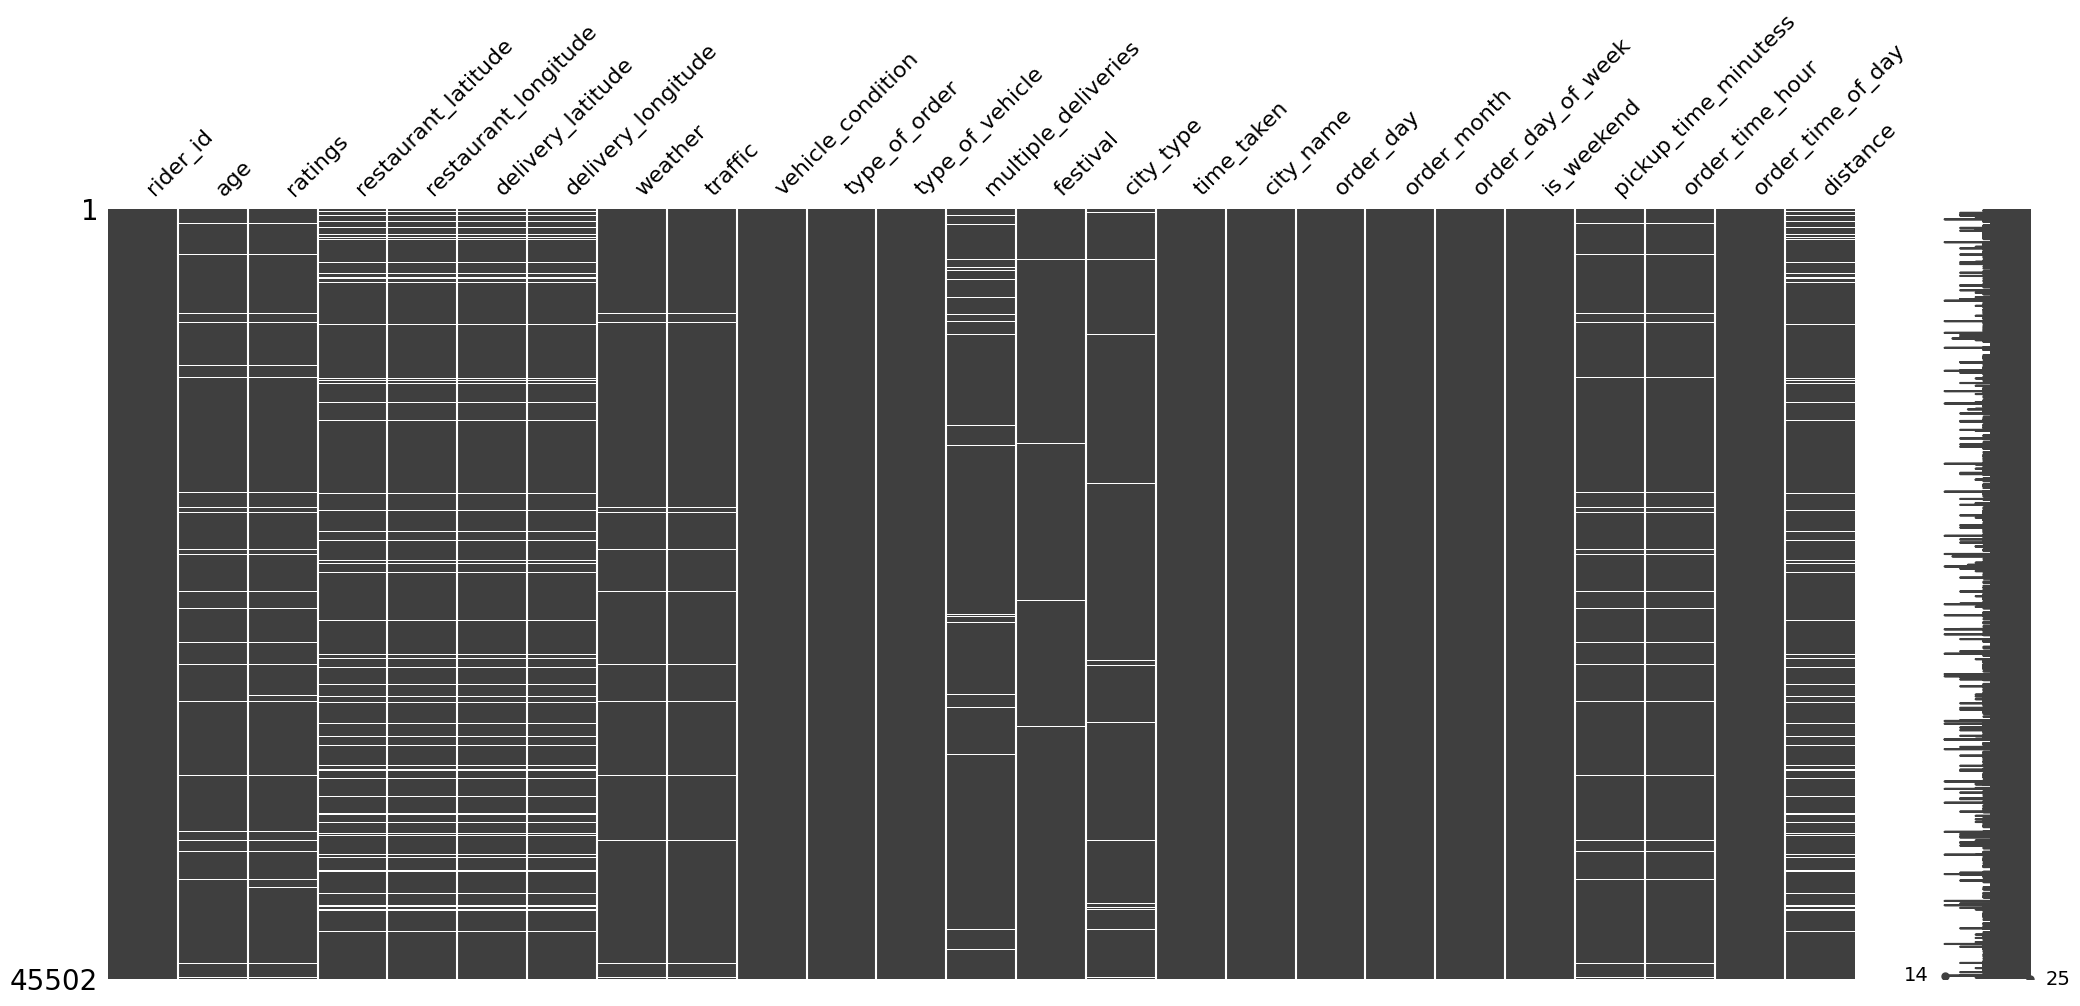

In [11]:
import missingno as msno
msno.matrix(df)

we can drop the columns latitude and logitude cols we can't impute these columns but we can impute the distance columns and we already made the new column that is distance and we have also city name column

<Axes: >

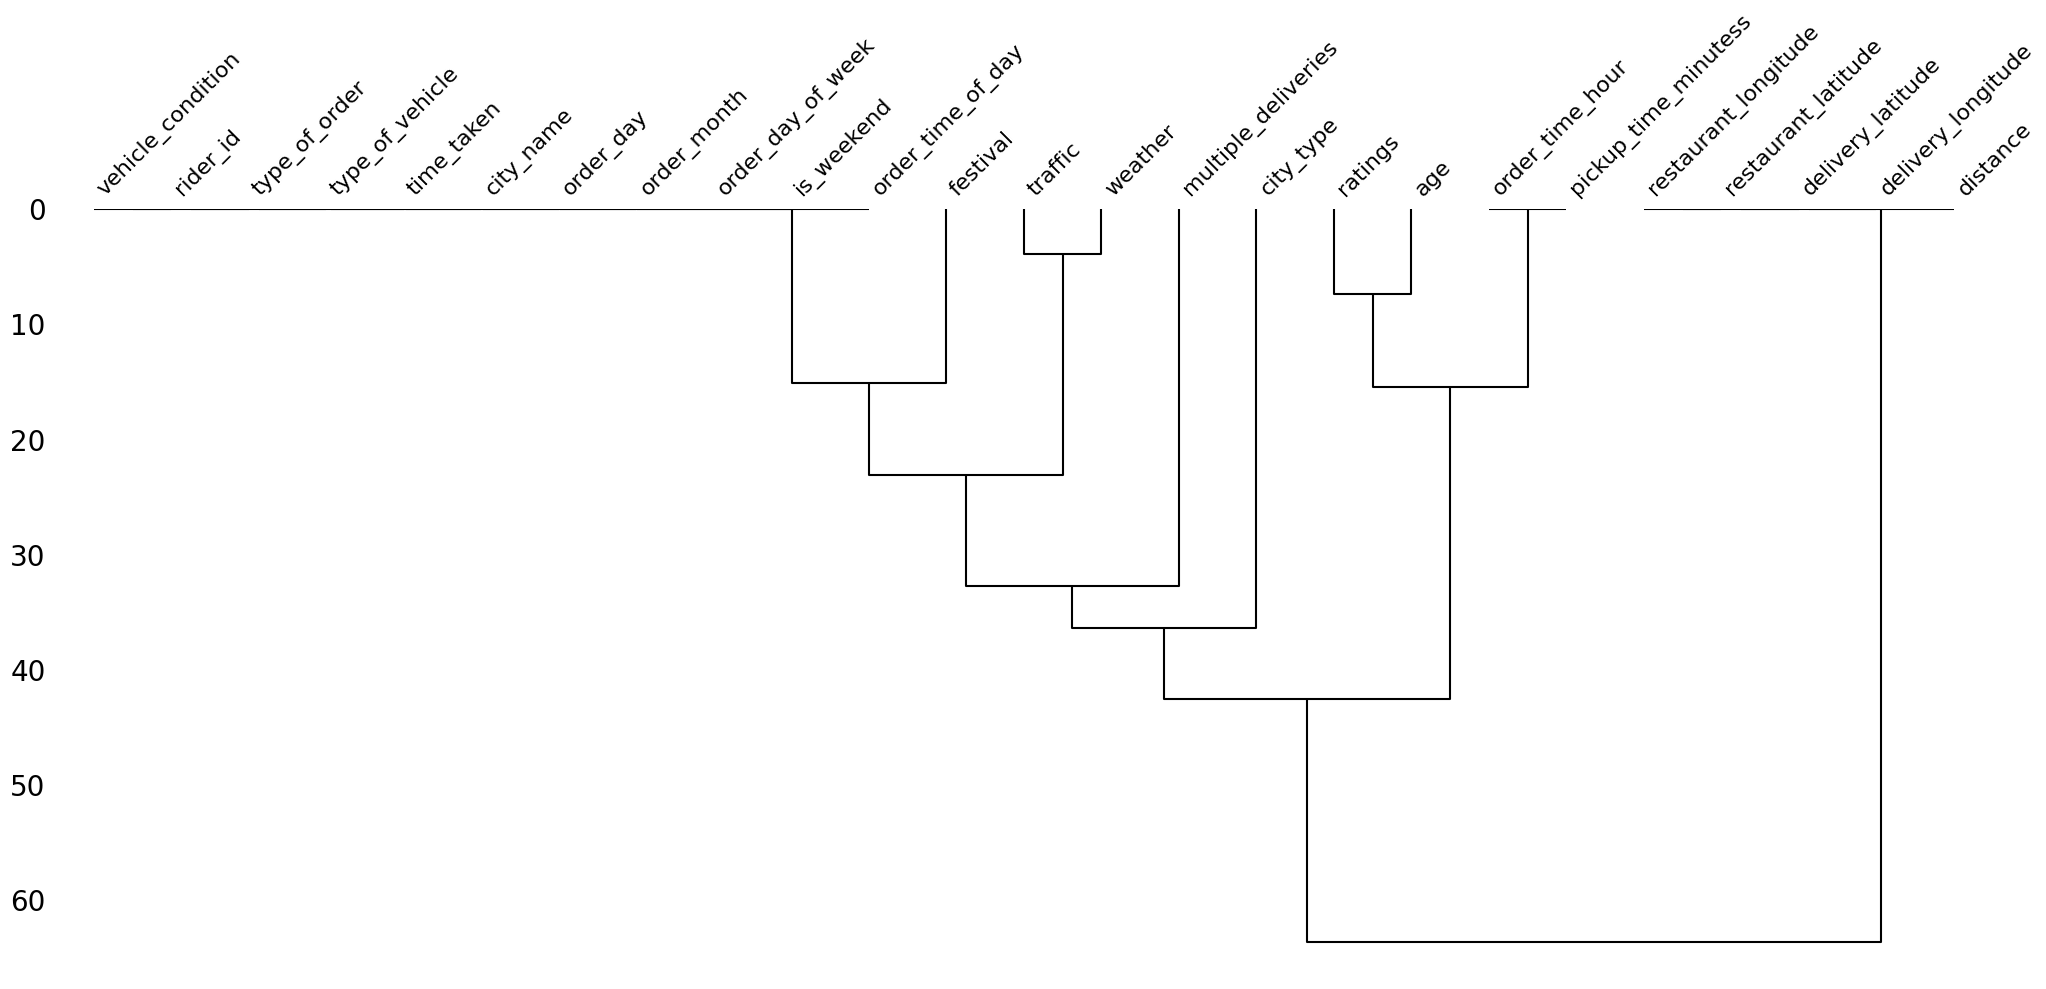

In [12]:
# msno.heatmap(df)
msno.dendrogram(df)

# functions to perform eda

In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # Corrected import for gridspec

def numerical_analysis(dataframe,column_name,cat_col=None,bins="auto"):
  # create the figure
  fig  = plt.figure(figsize=(10,5))
  # generate layout
  grid = gridspec.GridSpec(ncols=2,nrows=2,figure=fig)
  # set subplot
  ax1 = fig.add_subplot(grid[0,0])
  ax2 = fig.add_subplot(grid[0,1])
  ax3 = fig.add_subplot(grid[1,:])

  # Prepare kwargs for hue parameter
  hue_args = {}
  if cat_col is not None:
      # Check if cat_col is a valid column in the dataframe
      if cat_col in dataframe.columns:
          hue_args['hue'] = cat_col
      else:
          print(f"Warning: Categorical column '{cat_col}' not found in DataFrame. Plotting without hue.")

  # plot the kdeplot
  sns.kdeplot(data=dataframe,x=column_name,ax=ax1, **hue_args)
  # plot the boxplot
  sns.boxplot(data=dataframe,x=column_name,ax=ax2, **hue_args)
  # plot the histplot
  # Combine the histogram and KDE into a single histplot call, optionally with hue
  if 'hue' in hue_args:
      sns.histplot(data=dataframe,x=column_name,ax=ax3, **hue_args)
  else:
      sns.histplot(data=dataframe,x=column_name,kde=True,ax=ax3) # If no cat_col, plot with KDE

  plt.tight_layout()
  plt.show()

def numerical_categorical_analysis(dataframe,cat_column_1,num_Columns):
  fig, axes =  plt.subplots(2,2,figsize=(15,7.5))
  ax00, ax01 = axes[0]
  ax10, ax11 = axes[1]

  # plot the barplot
  sns.barplot(data=dataframe,x=cat_column_1,y=num_Columns,ax=ax00)
  # plot the boxplot
  sns.boxplot(data=dataframe,x=cat_column_1,y=num_Columns,ax=ax01)
  # plot violin plot
  sns.violinplot(data=dataframe,x=cat_column_1,y=num_Columns,ax=ax10)      #### kde plot and boxplot mixture
  # plot strip plot
  sns.stripplot(data=dataframe,x=cat_column_1,y=num_Columns,ax=ax11)       ### strip use for check distribution of data
  plt.tight_layout()
  plt.show()

  ##---------- univarient categorical analysis

def categorical_analysis(dataframe,column_name):
  # print the values counts of categories and its percentage
     display(
      pd.DataFrame({
          "Count":dataframe[column_name].value_counts(),
          "Percentage":dataframe[column_name].value_counts(normalize=True).mul(100).round(2).astype("str").add('%')
      })
     )
     ## get unique categories
     unique_categories = dataframe[column_name].unique().tolist()
     number_of_unique_categories = len(unique_categories)
     print(f'number of unique categories {number_of_unique_categories}')
     print('*'*50)
     print(f'number of catgories in {column_name} columns are {number_of_unique_categories}')
     # plot the countplot
     sns.countplot(data=dataframe,x=column_name)
     plt.xticks(rotation=45)
     plt.show()

def  multivariate_analysis(dataframe,num_Columns,cat_column_1,cat_columns_2):
  fig, (ax1,ax2) = plt.subplots(2,2,figsize=(15,7.5))
  # plt the barplot
  sns.barplot(data=dataframe,x=cat_column_1,y=num_Columns,hue=cat_columns_2,ax=ax1[0])
  # plot the boxplot
  sns.boxplot(data=dataframe,x=cat_column_1,y=num_Columns,hue=cat_columns_2,gap = 0.1,ax=ax1[1])
  # plot the violin plot
  sns.violinplot(data=dataframe,x=cat_column_1,y=num_Columns,hue=cat_columns_2,ax=ax2[0])
  #plot strip plot
  sns.stripplot(data=dataframe,x=cat_column_1,y=num_Columns,hue=cat_columns_2,dodge=True,ax=ax2[1])
  plt.tight_layout()
  plt.show()

def chi_2_test(dataframe,col1,col2,alpha=0.05):
  data = (
      dataframe.loc[:,[col1,col2]]
      .dropna()
  )
  # create contingency table
  contingency_table = pd.crosstab(data[col1],data[col2])
  #perform chi-squared test
  _,p_val,_,_ = stats.chi2_contingency(contingency_table)
  print(p_val)
  if p_val < alpha :
    print(f'reject null hypothesis there is a significant association between {col1} and {col2}. ')
  else:
    print(f'fail to reject null hypothesis there is no significant association between {col1} and {col2}. ')

def anova_test(dataframe,num_col,cat_col,alpha=0.05):
  data  =  (
      dataframe.loc[:,[num_col,cat_col]]
      .dropna()
  )

  cat_group = data.groupby(cat_col)
  groups = [group[1][num_col].values for group in cat_group] # Corrected line
  f_stat,p_val = stats.f_oneway(*groups)
  print(p_val)
  if p_val < alpha :
    print(f'reject null hypothesis there is a significant association between {num_col} and {cat_col}. ')
  else:
    print(f'fail to reject null hypothesis there is no significant association between {num_col} and {cat_col}. ')

#####------- for large data we use jar_que bera not  others because they are reliable for small datset

def test_for_normality(dataframe,column_name,alpha=0.05):
  data = dataframe[column_name]
  print(f' jarque bera test for normality')
  _,p_val = stats.jarque_bera(data)
  print(p_val)
  if p_val < alpha :
    print(f'reject null hypothesis data is not normally distributed')
  else:
    print(f'data is normally distributed')

# Time taken (target column)

In [14]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'weather', 'traffic', 'vehicle_condition', 'type_of_order',
       'type_of_vehicle', 'multiple_deliveries', 'festival', 'city_type',
       'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutess',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

In [15]:
df['time_taken'].dtype

dtype('int64')

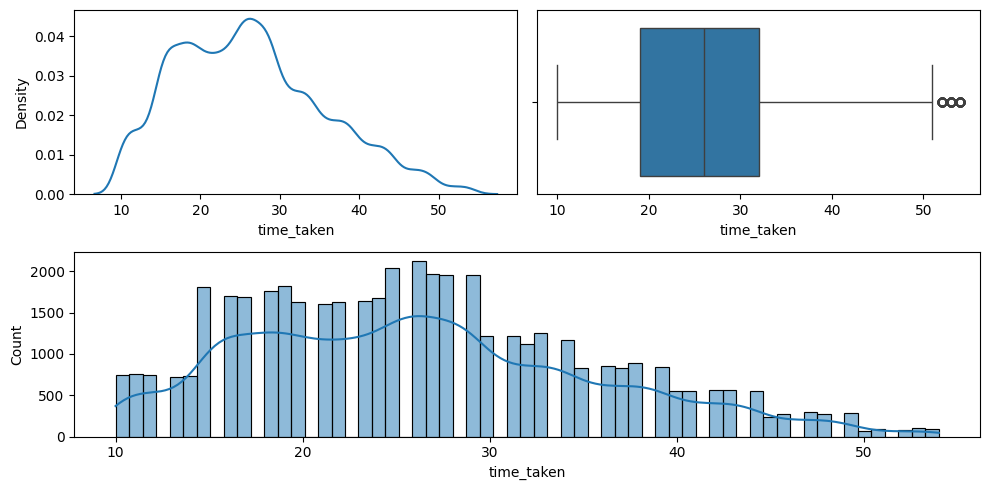

In [16]:
# numerical analysis

numerical_analysis(df,'time_taken',bins =10)

----------observation:
1.target columns show dual modality with two peaks one is around  16-17 and one is around 26-27

2.so target column is not fully continuous in nature

3.taget column have some extreme points which can be thought of as outlier but they are just extream not rare ,not outlier 50 min time is possible in certian rare case

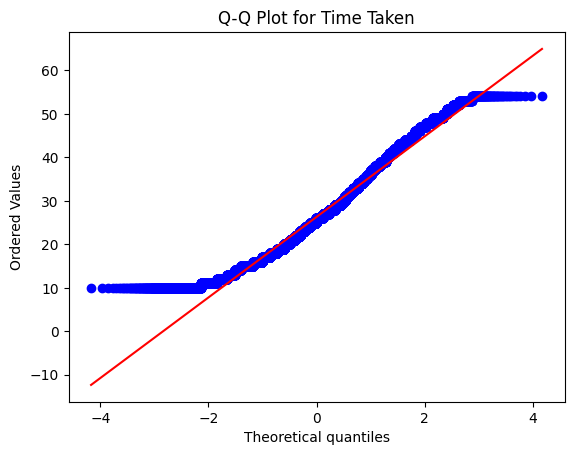

In [17]:
## qq plot for the target dataset
import scipy.stats as stats

stats.probplot(df["time_taken"], dist="norm", plot=plt)
plt.title("Q-Q Plot for Time Taken")
plt.show()

In [18]:
# test for normality
test_for_normality(df,'time_taken')

 jarque bera test for normality
0.0
reject null hypothesis data is not normally distributed


In [19]:
# check out rows where data act as outlier  beacause of which column

target_25_per,target_75_per = np.percentile(df['time_taken'],[25,75])

iqr = target_75_per - target_25_per

upper_bound = target_75_per + (1.5 * iqr)

df.loc[df['time_taken'] > upper_bound,'traffic'].value_counts()


,count
traffic,
jam,241
high,24


time taken is depend on traffic

In [20]:
df.loc[df['time_taken'] > upper_bound,'weather'].value_counts()

,count
weather,
fog,57
sunny,51
windy,44
cloudy,44
stormy,37
sandstorms,32


not depends on the weather

In [21]:
# average distance impact
avg_dist = df.loc[:,'distance'].mean()
avg_dist
avg_dist_extrem = df.loc[df['time_taken'] > upper_bound,'distance'].mean()
avg_dist_extrem
# avg_dist

np.float64(13.29215081388658)

avgerage distance of extrem value is large means it is due to large distance

In [22]:
## apply transformer on the target column of the data and after this transformer check the distribution
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df['time_taken_transformed'] = pt.fit_transform(df[['time_taken']])

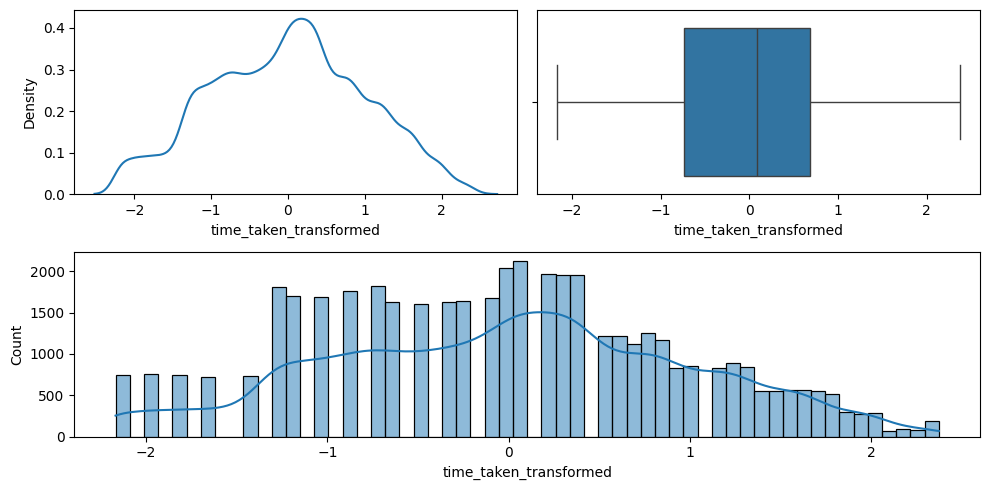

In [23]:
numerical_analysis(df,'time_taken_transformed',bins =10)

In [24]:
df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,weather,traffic,vehicle_condition,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutess,order_time_hour,order_time_of_day,distance,time_taken_transformed
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,sunny,high,2,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,-0.130153
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,stormy,jam,2,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,0.775092
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,sandstorms,low,0,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,0.088493
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,sunny,medium,0,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,-0.482135
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,cloudy,high,1,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,0.494134


#rider id

In [25]:
# check for duplicate
df['rider_id'].dropna().duplicated(keep=False).sum()

np.int64(45502)

In [26]:
(
    df.loc[df['rider_id'].duplicated(keep=False),['rider_id','age','ratings']].dropna().sort_values('rider_id')
)

,rider_id,age,ratings
24549,AGRRES010DEL01,20.0,4.8
29220,AGRRES010DEL01,36.0,4.9
20201,AGRRES010DEL01,34.0,4.9
15344,AGRRES010DEL01,25.0,5.0
18207,AGRRES010DEL01,38.0,5.0
...,...,...,...
26256,VADRES20DEL03,34.0,4.6
42592,VADRES20DEL03,34.0,4.8
25554,VADRES20DEL03,26.0,5.0
5094,VADRES20DEL03,35.0,4.9


there are value of id duplicate then value of age and ratings are same but not always so we can't impute using.

#Age

In [27]:
# datatype of age columns
df['age'].dtype

dtype('float64')

In [28]:
df['age'].describe()

,age
count,43648.000000
mean,29.555008
std,5.761482
min,20.000000
25%,25.000000
50%,30.000000
75%,35.000000
max,39.000000


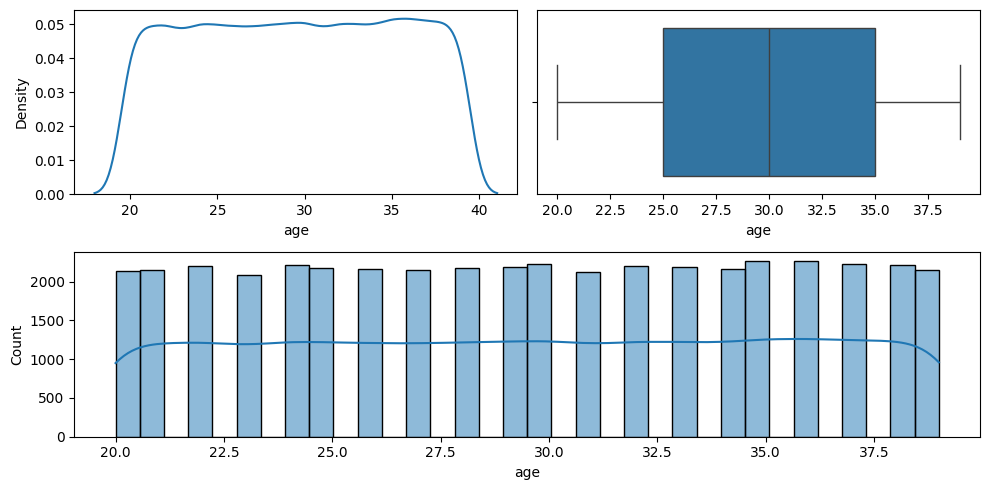

In [29]:
numerical_analysis(df,'age',bins =10)

age distribution is uniform in between 21 to 39

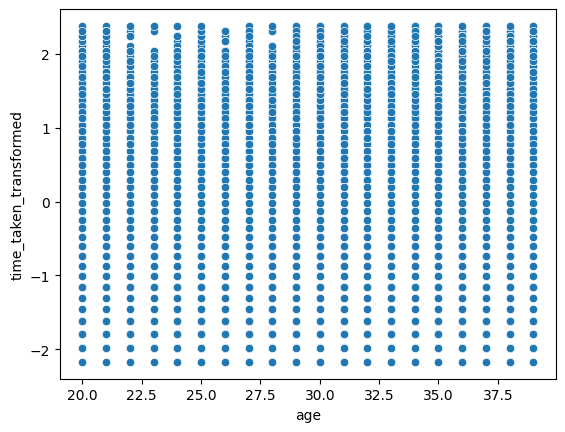

In [30]:
# realtionship between target and age
sns.scatterplot(data = df,x ='age',y='time_taken_transformed')
plt.show()

delivery time is not depend upon the age and age is discret type column

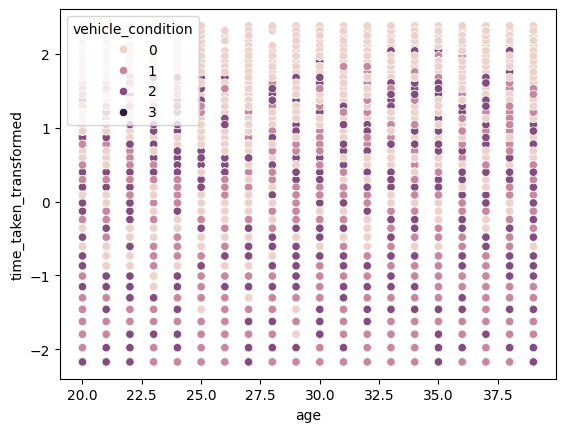

In [31]:
sns.scatterplot(data = df,x ='age',y='time_taken_transformed',hue='vehicle_condition')
plt.show()

In [32]:
df.head()

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,weather,traffic,vehicle_condition,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutess,order_time_hour,order_time_of_day,distance,time_taken_transformed
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,sunny,high,2,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,-0.130153
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,stormy,jam,2,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,0.775092
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,sandstorms,low,0,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,0.088493
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,sunny,medium,0,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,-0.482135
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,cloudy,high,1,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,0.494134


according to age vechicle preference

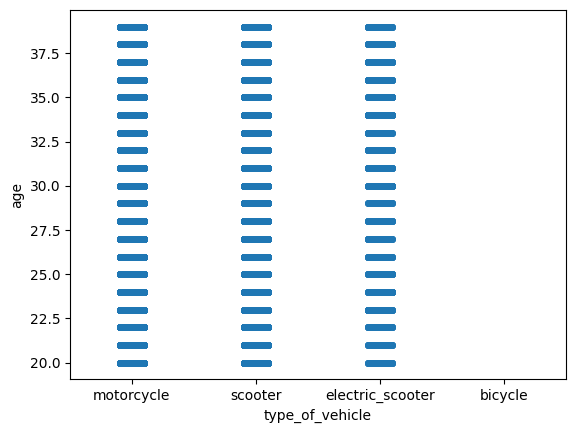

In [33]:
sns.stripplot(data = df, x='type_of_vehicle',y='age')
plt.show()

no reation with type of vechical with age

ratings

In [34]:
df['ratings'].dtypes

dtype('float64')

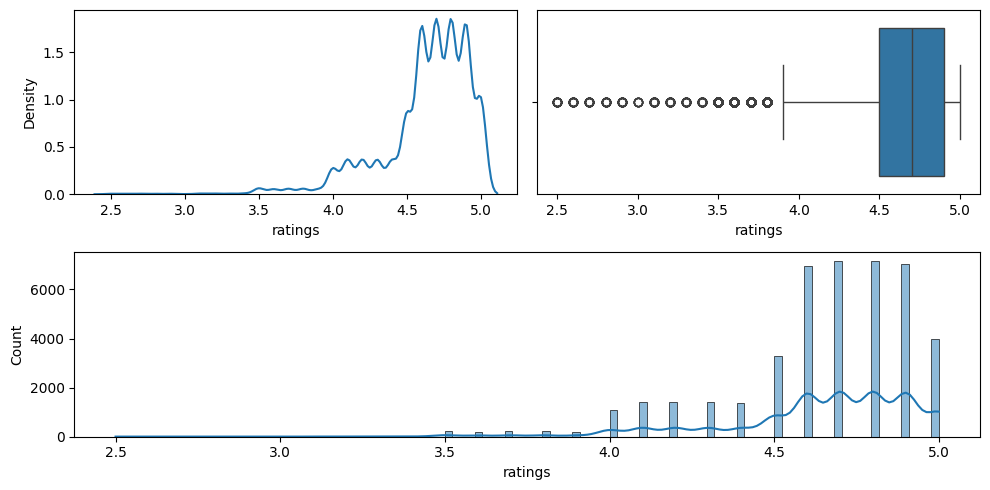

In [35]:
numerical_analysis(df,'ratings',bins =10)

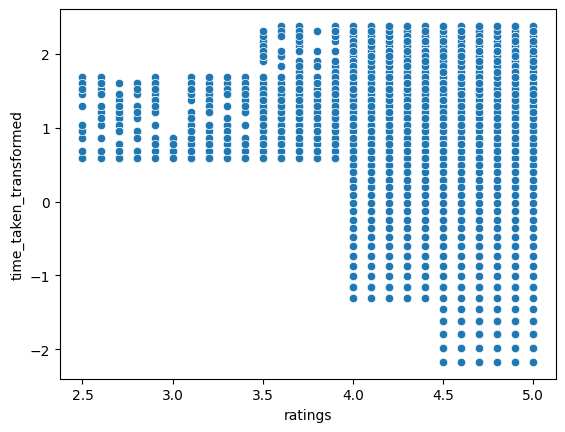

In [36]:
# does rating affect delivery time
sns.scatterplot(data = df,x ='ratings',y='time_taken_transformed')
plt.show()

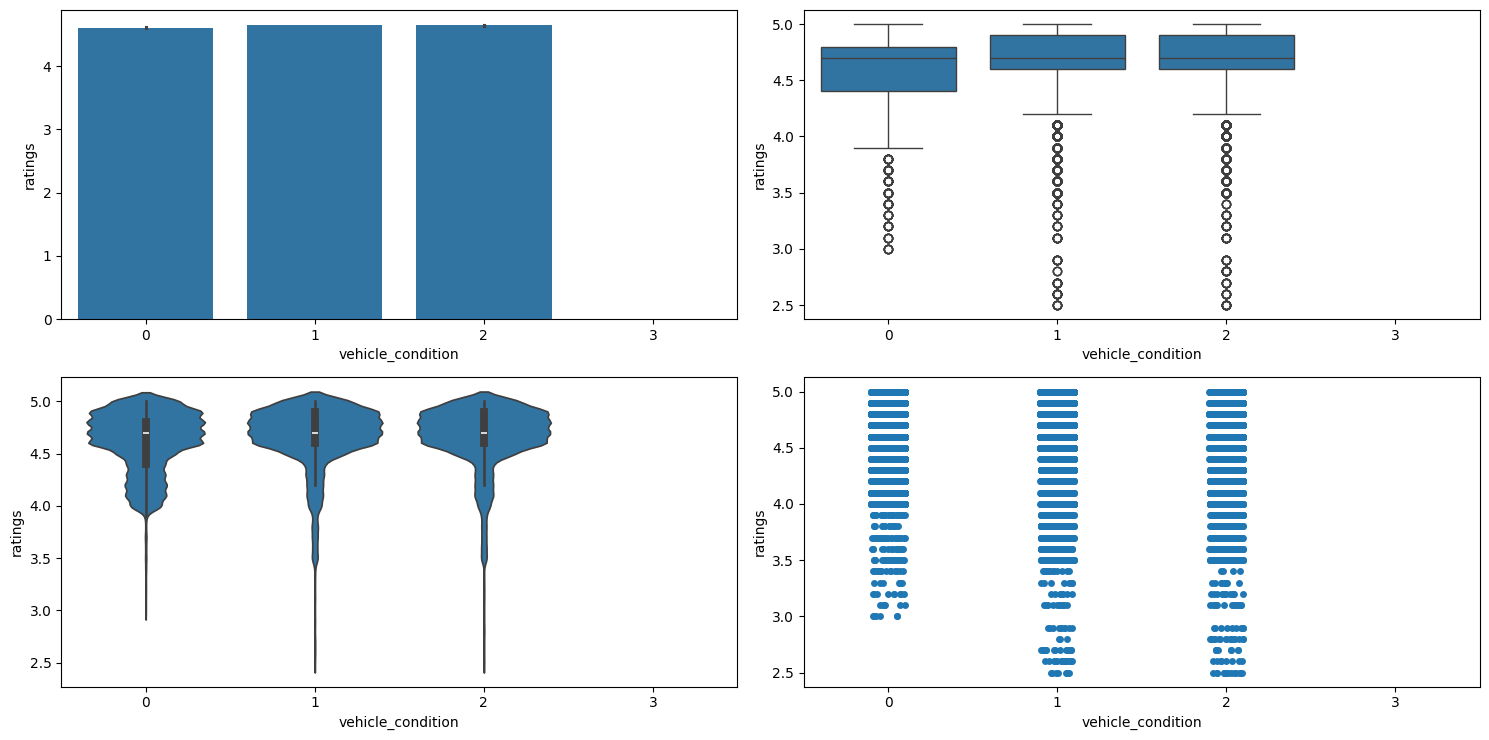

In [37]:
## rating with vechical type
numerical_categorical_analysis(df,'vehicle_condition','ratings')

vehicle condition affect the rating here

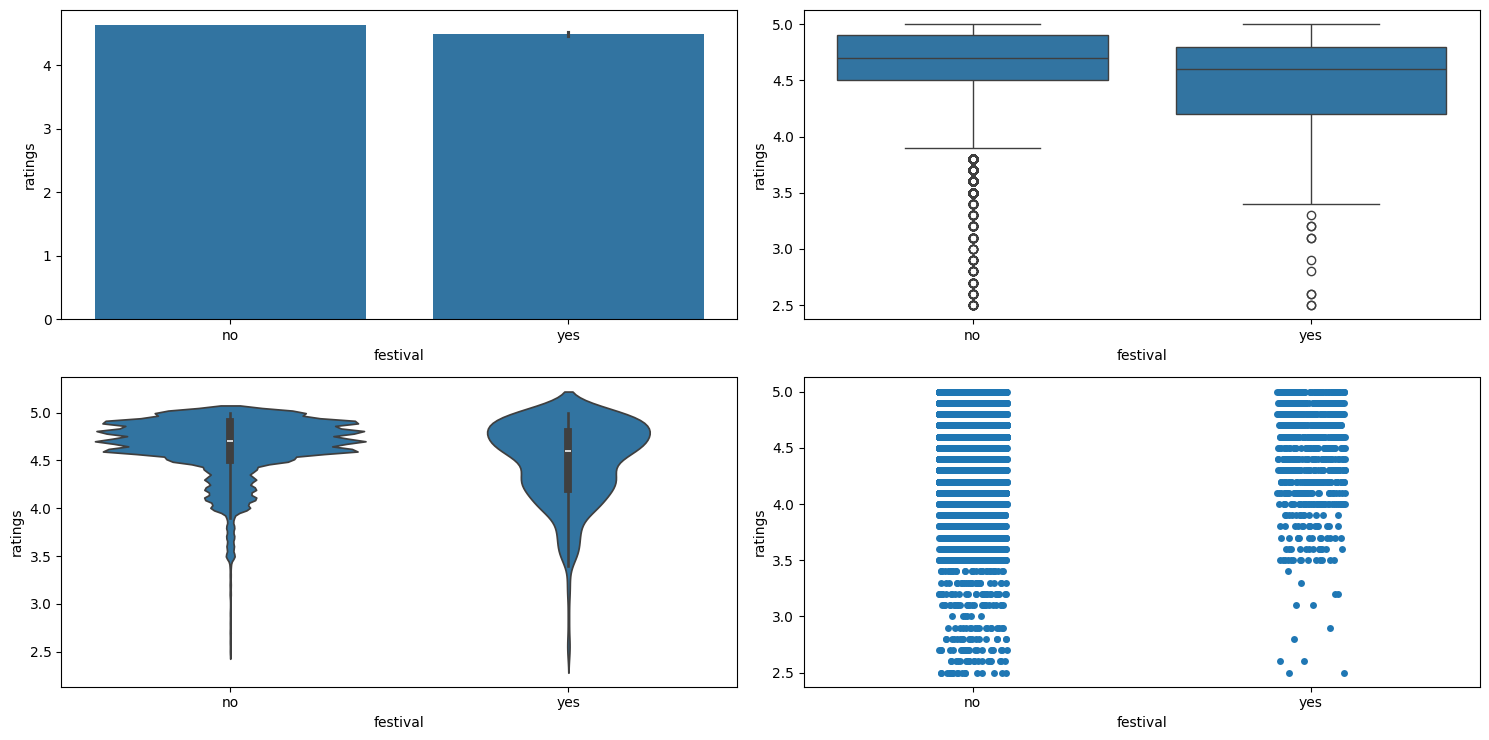

In [38]:
# festival and rating

numerical_categorical_analysis(df,'festival','ratings')

In [39]:
location_subset = df.columns[3:7].tolist() + ['city_name']
df[location_subset]

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45497,26.902328,75.794257,26.912328,75.804257,JAP
45498,NaN,NaN,NaN,NaN,AGR
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [40]:
#plot delivery on map

delivery_df = pd.DataFrame({
    'latitude': df['delivery_latitude'],
    'longitude': df['delivery_longitude'],
    'city_name': df['city_name']
})

# create a map using plotly's scatter_mapbox
import plotly.express as px

fig = px.scatter_mapbox(
    delivery_df.dropna(),
    lat="latitude",
    lon="longitude",
    hover_name="city_name",
    zoom=3, # Initial zoom level
    height=600,
    title="Delivery Locations in India"
)

# update the layout for the map of india
fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={
        "lat": 20.5937,
        "lon": 78.9629
    }, # Center of India
    mapbox_zoom=3.5 # Adjusted zoom for India
)

fig.show()

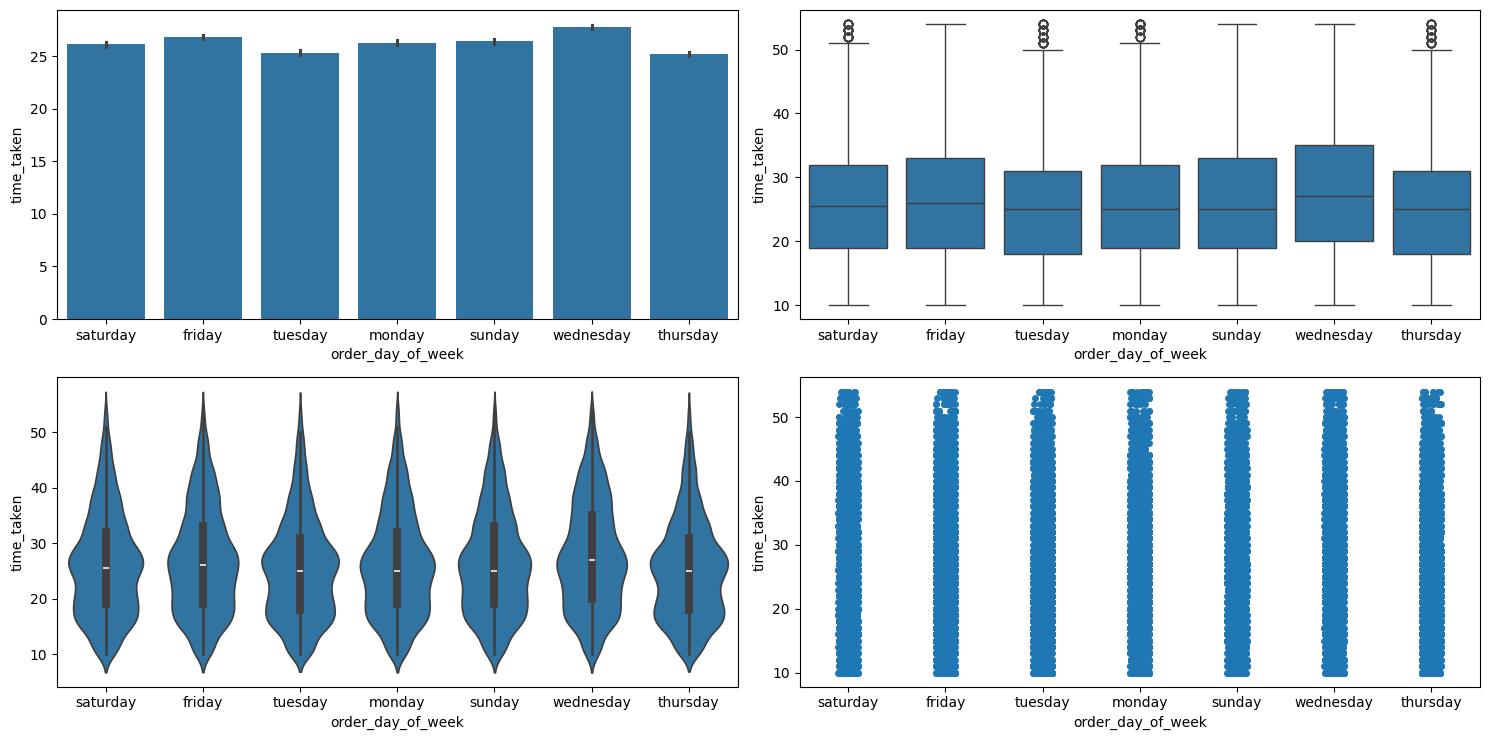

In [41]:
# analysis between day of week and target
numerical_categorical_analysis(df,'order_day_of_week','time_taken')

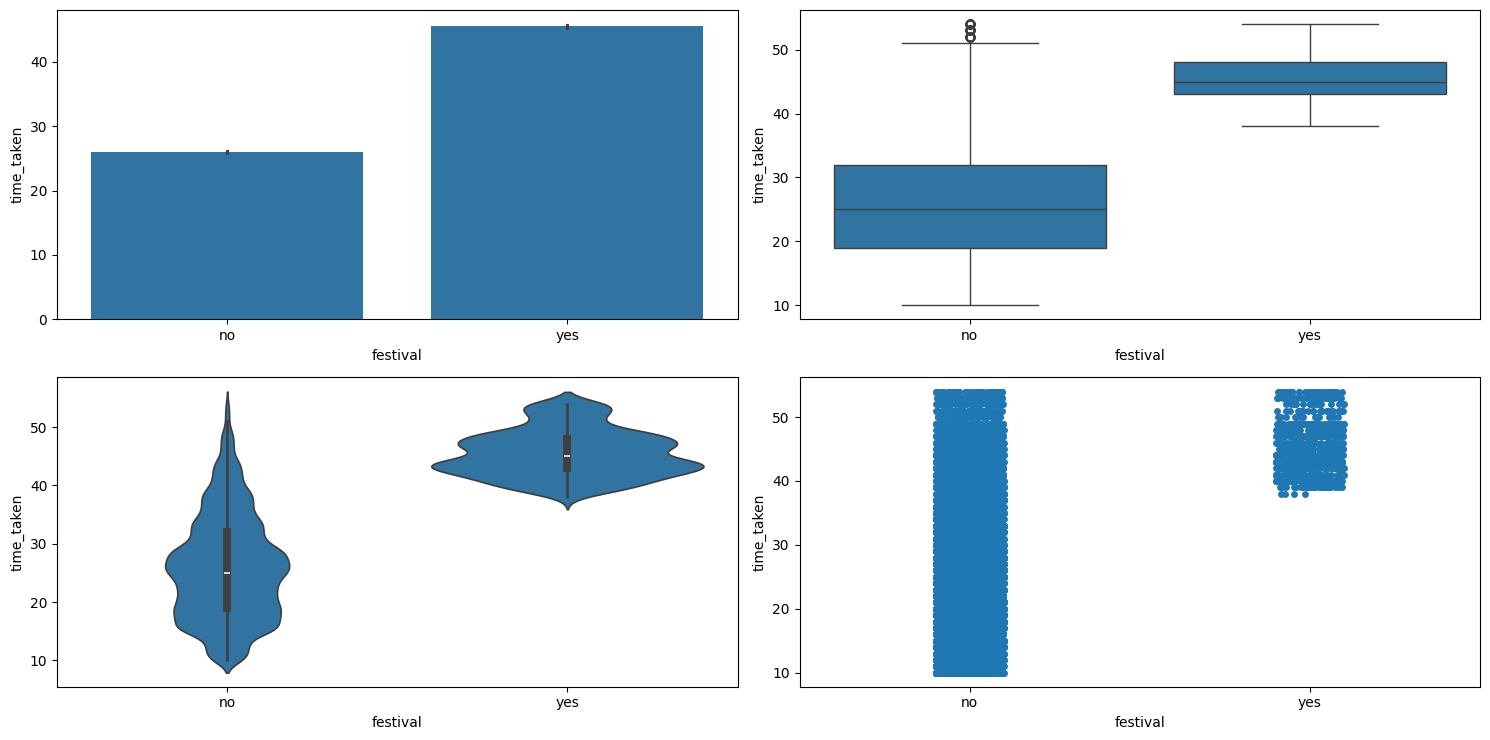

In [42]:
# festival and time_taken
numerical_categorical_analysis(df,'festival','time_taken')

festival delivery time usually takes longer.

In [43]:
# do festivel affect the traffic
chi_2_test(df,'festival','traffic')


1.1223471129146869e-153
reject null hypothesis there is a significant association between festival and traffic. 


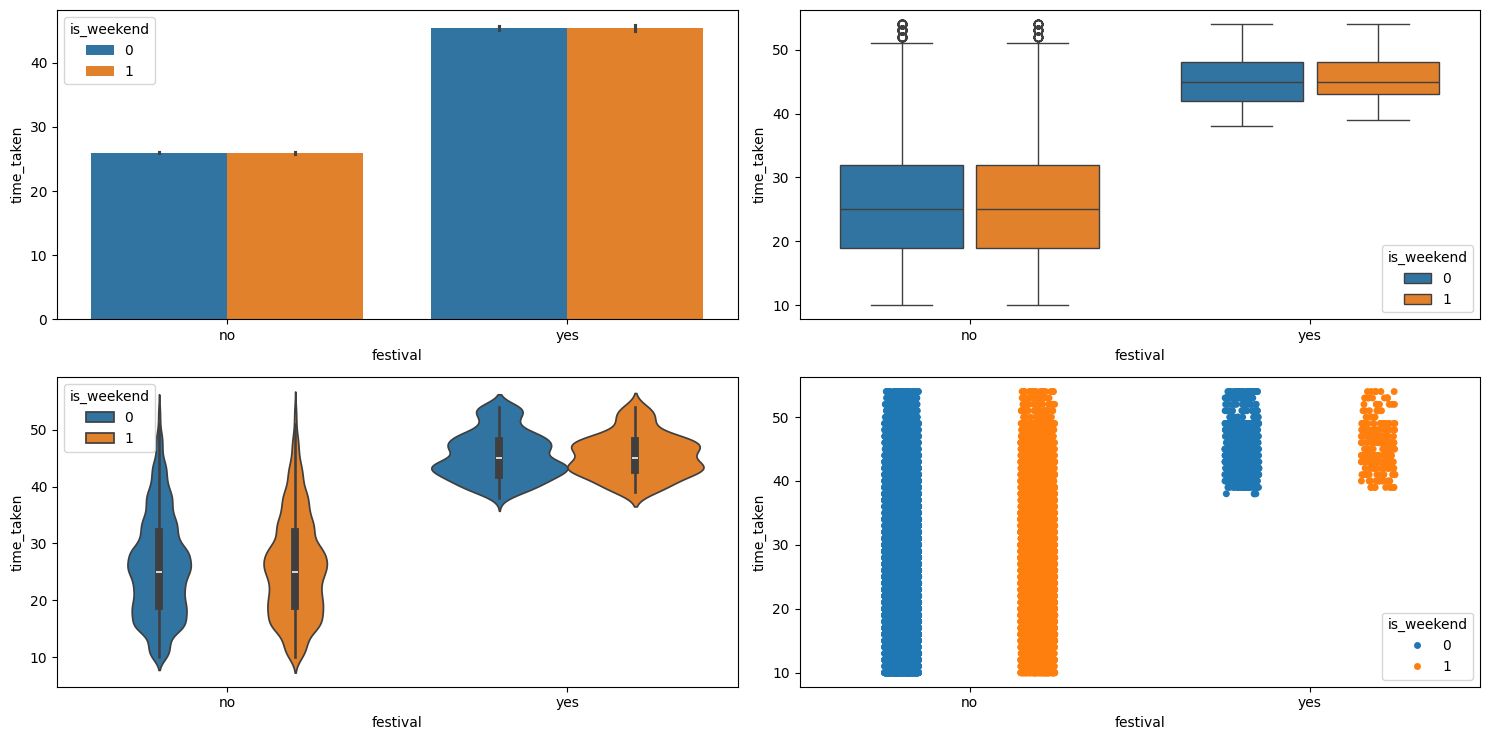

In [44]:
multivariate_analysis(df,'time_taken','festival','is_weekend')

order time

In [45]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'weather', 'traffic', 'vehicle_condition', 'type_of_order',
       'type_of_vehicle', 'multiple_deliveries', 'festival', 'city_type',
       'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutess',
       'order_time_hour', 'order_time_of_day', 'distance',
       'time_taken_transformed'],
      dtype='object')

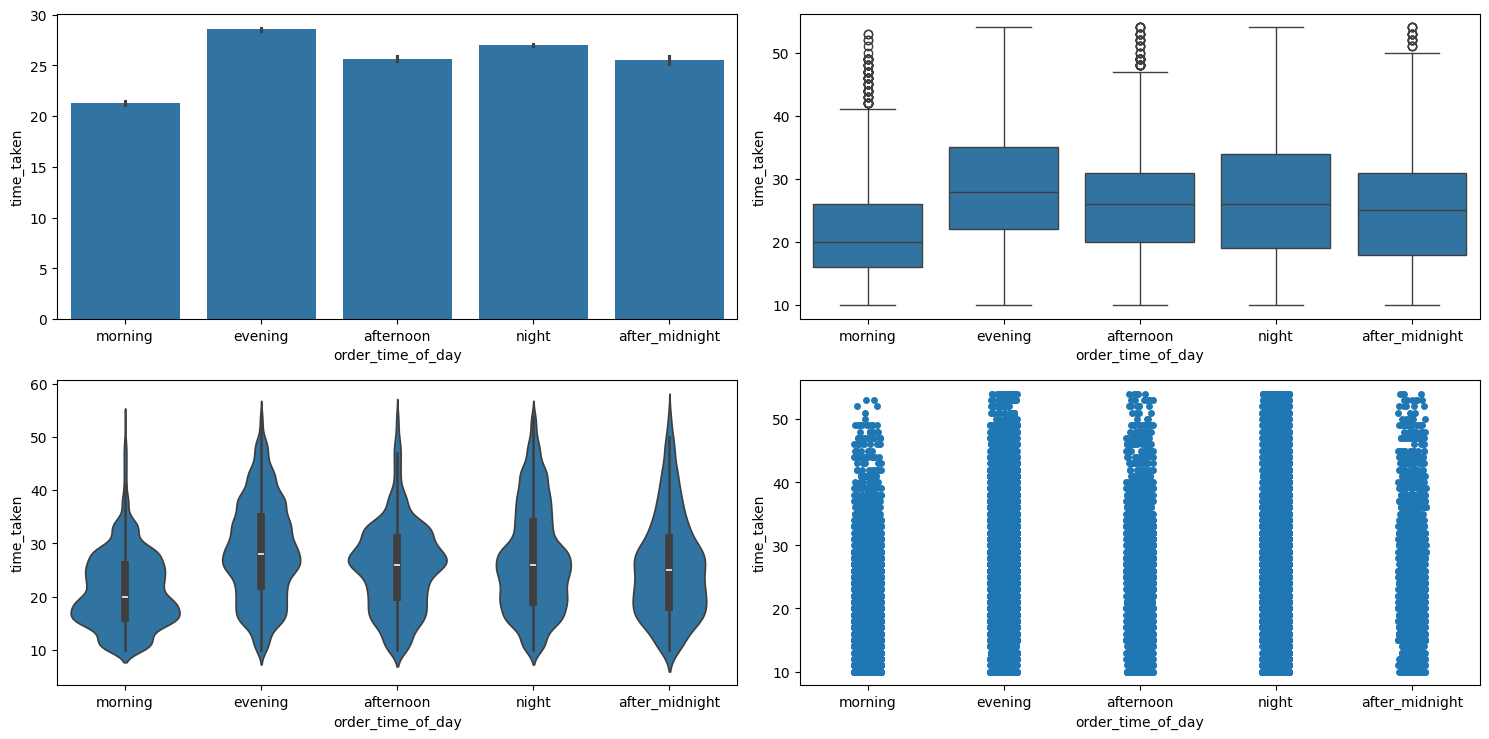

In [46]:
# does order time of dat affect  delivery times
numerical_categorical_analysis(df,'order_time_of_day','time_taken')

In [47]:
# anova test
anova_test(df,'time_taken','order_time_of_day')

0.0
reject null hypothesis there is a significant association between time_taken and order_time_of_day. 


,Count,Percentage
order_time_hour,,
21.0,4686,10.68%
19.0,4595,10.48%
22.0,4576,10.43%
20.0,4539,10.35%
23.0,4511,10.28%
18.0,4480,10.21%
17.0,4278,9.75%
10.0,1991,4.54%
11.0,1962,4.47%


number of unique categories 18
**************************************************
number of catgories in order_time_hour columns are 18


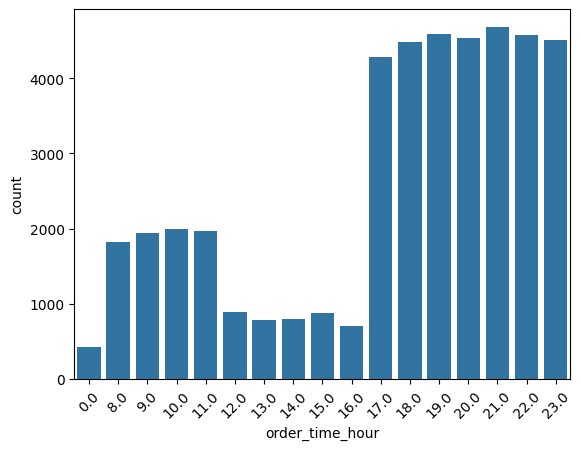

In [48]:
# categorical  analysis on order_time_hour
categorical_analysis(df,'order_time_hour')

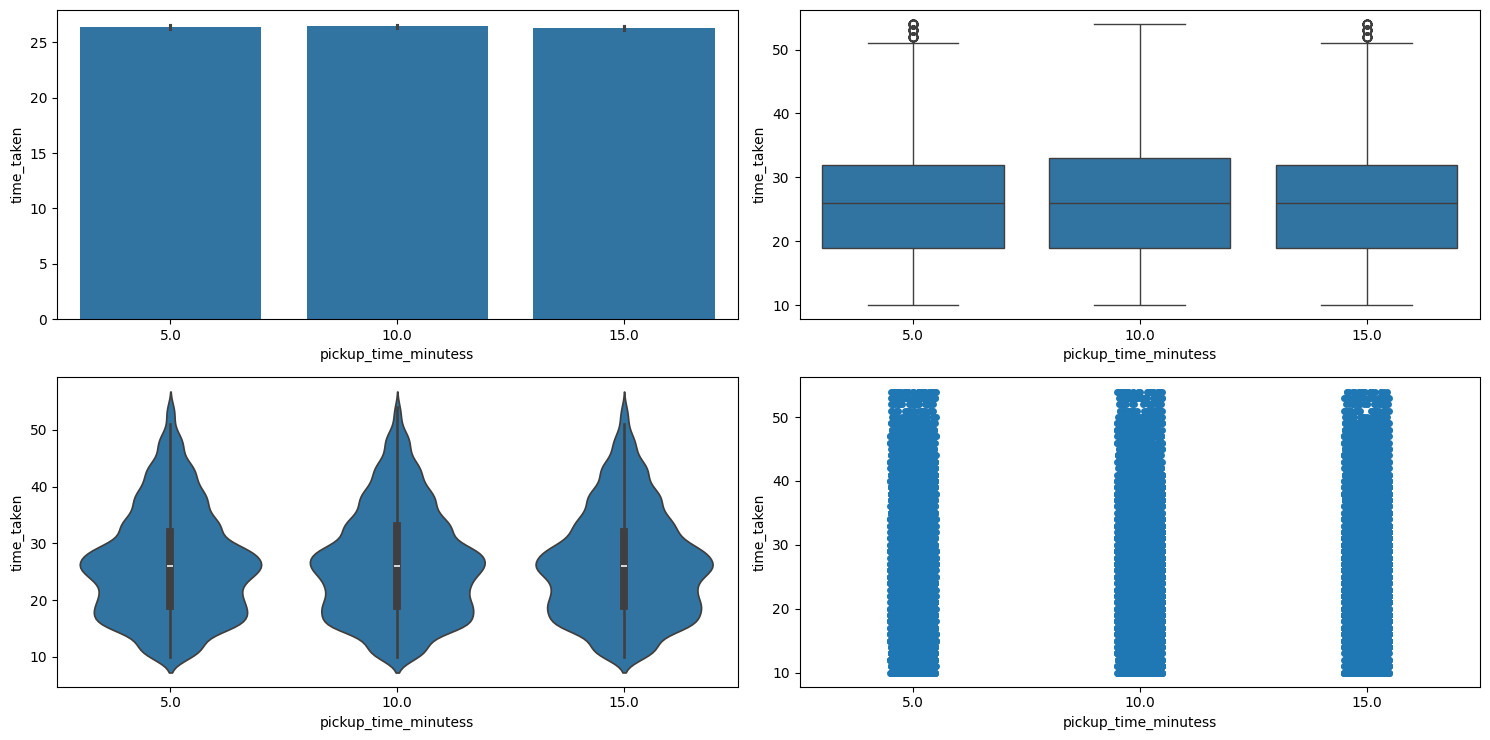

In [49]:
# pickup time have affect on the delivery time
df.loc[df['pickup_time_minutess'] < 0, 'pickup_time_minutess'] = np.nan
numerical_categorical_analysis(df,'pickup_time_minutess','time_taken')

In [50]:
# hypothesis test
anova_test(df,'time_taken','pickup_time_minutess')

0.3180300792791558
fail to reject null hypothesis there is no significant association between time_taken and pickup_time_minutess. 


traffic

,Count,Percentage
traffic,,
low,15477,34.4%
jam,14143,31.43%
medium,10947,24.33%
high,4425,9.84%


number of unique categories 5
**************************************************
number of catgories in traffic columns are 5


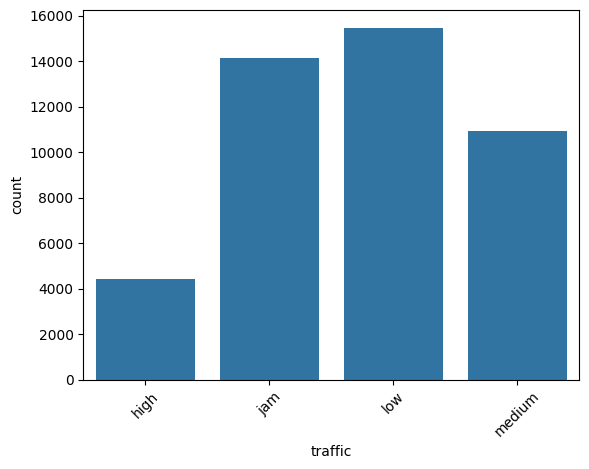

In [51]:
# datatype of trafic columns
df['traffic'].dtype
# categorical analysis on traffic
categorical_analysis(df,'traffic')

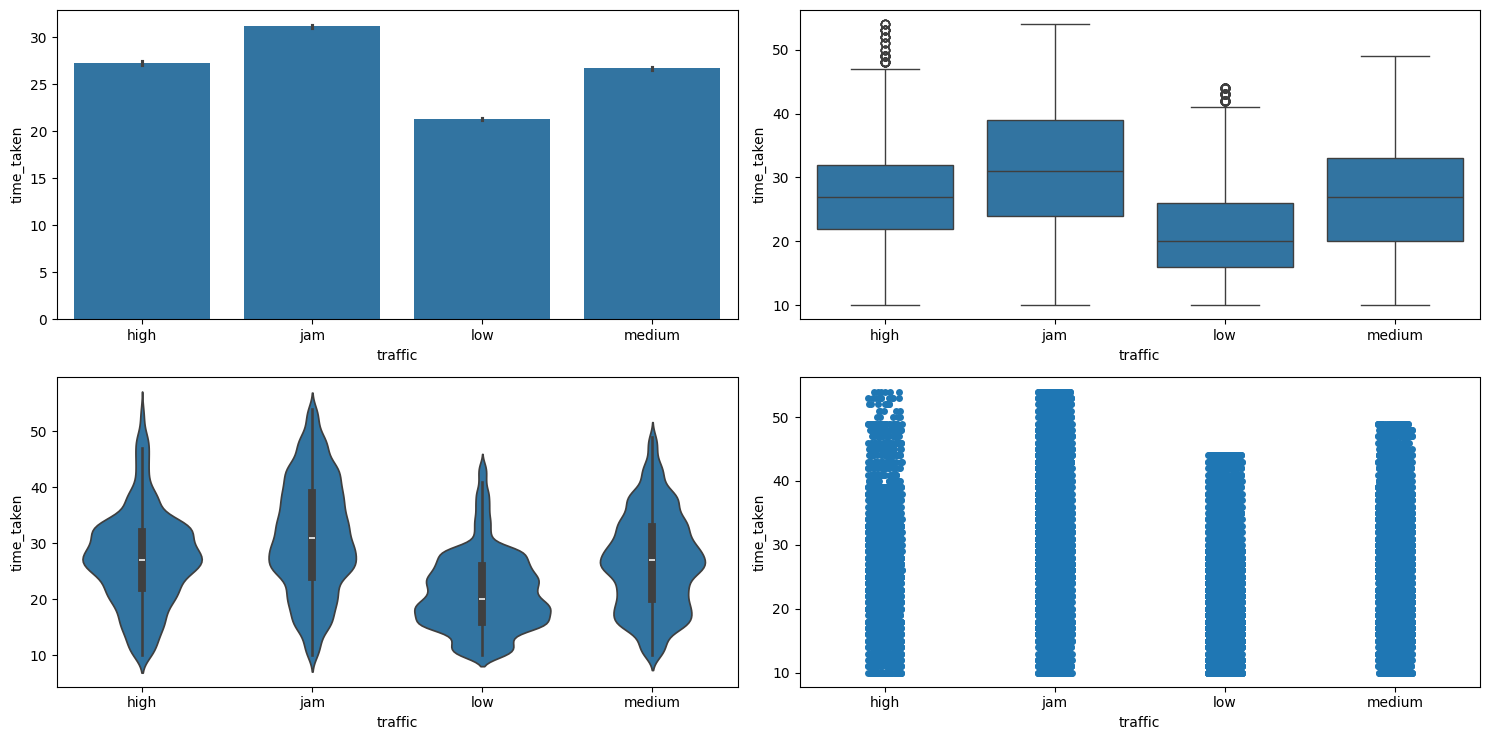

In [52]:
# traffic vs delivery time
numerical_categorical_analysis(df,'traffic','time_taken')

In [53]:
anova_test(df,'time_taken','traffic')

0.0
reject null hypothesis there is a significant association between time_taken and traffic. 


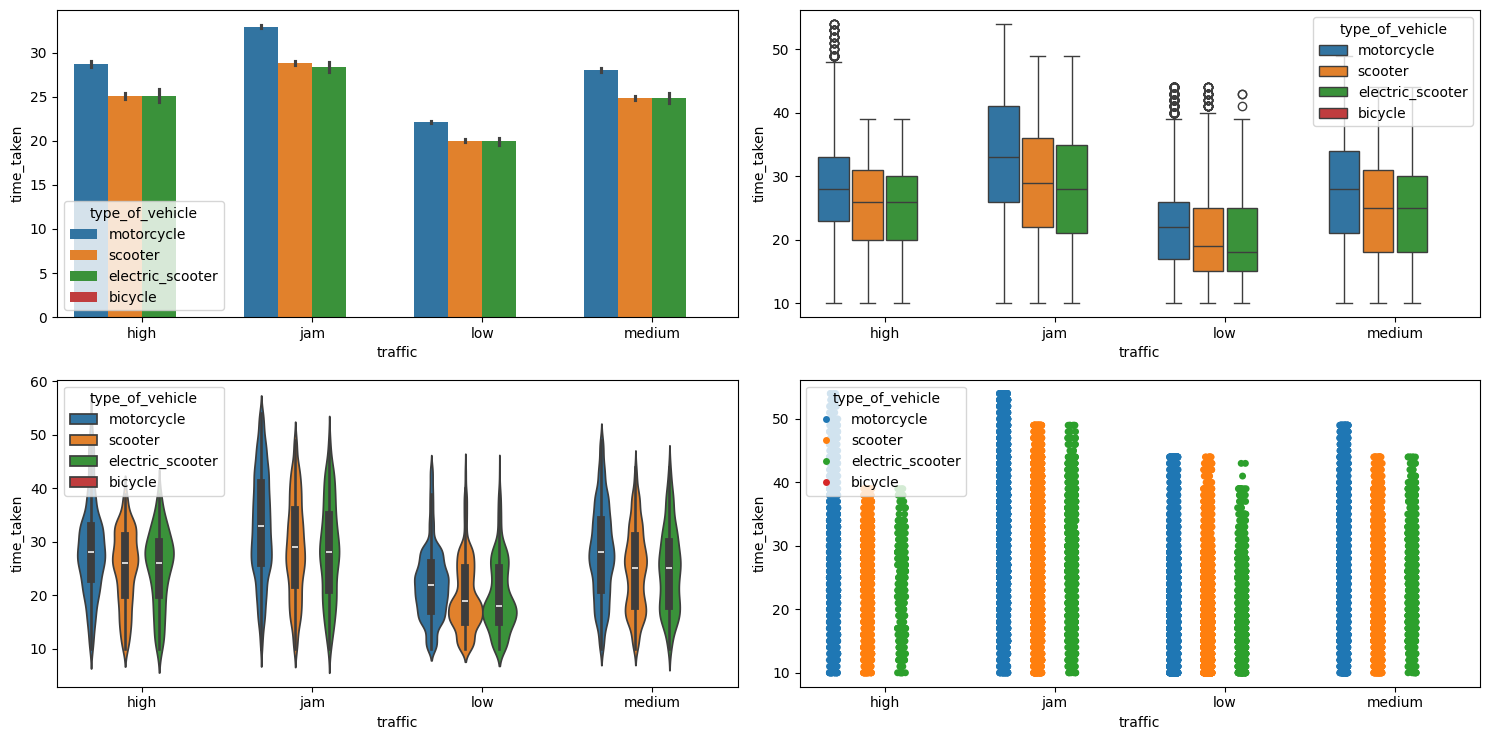

In [54]:
# are some vechicle types more suitable in traffic than others

multivariate_analysis(df,'time_taken','traffic','type_of_vehicle')

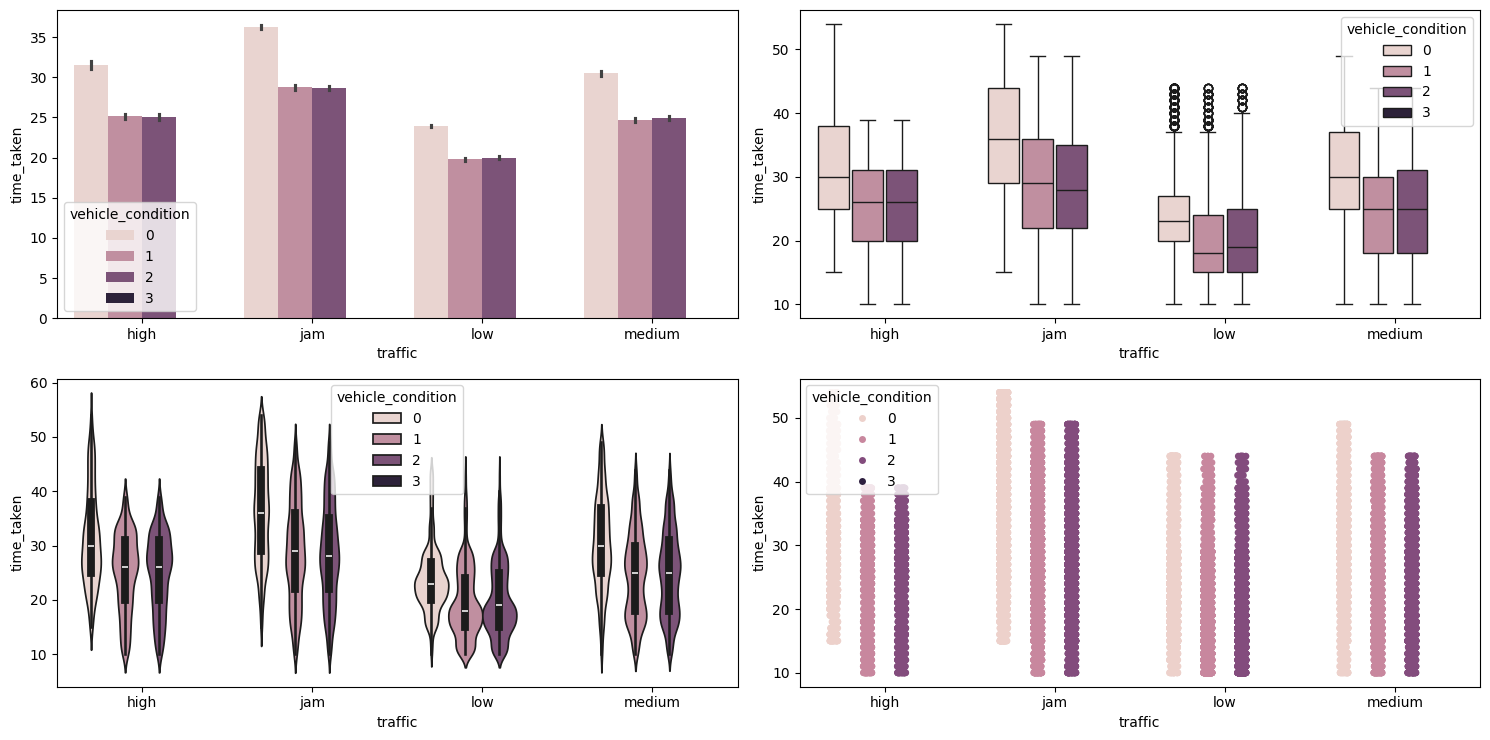

In [55]:
# does vehicle condition in traffic affect the delivery time
multivariate_analysis(df,'time_taken','traffic','vehicle_condition')

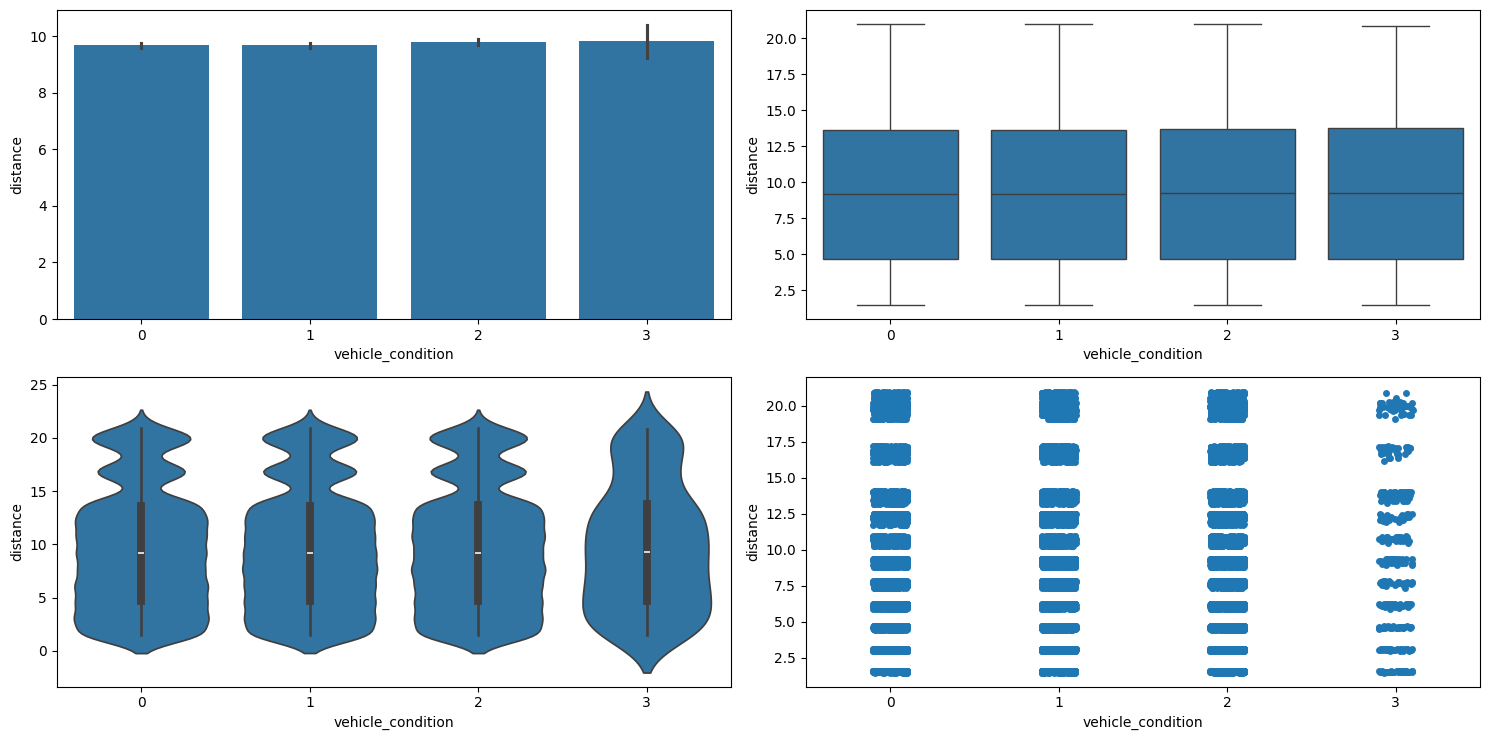

In [56]:
numerical_categorical_analysis(df,'vehicle_condition','distance')


on vehicle not depend not depends on the delivery time

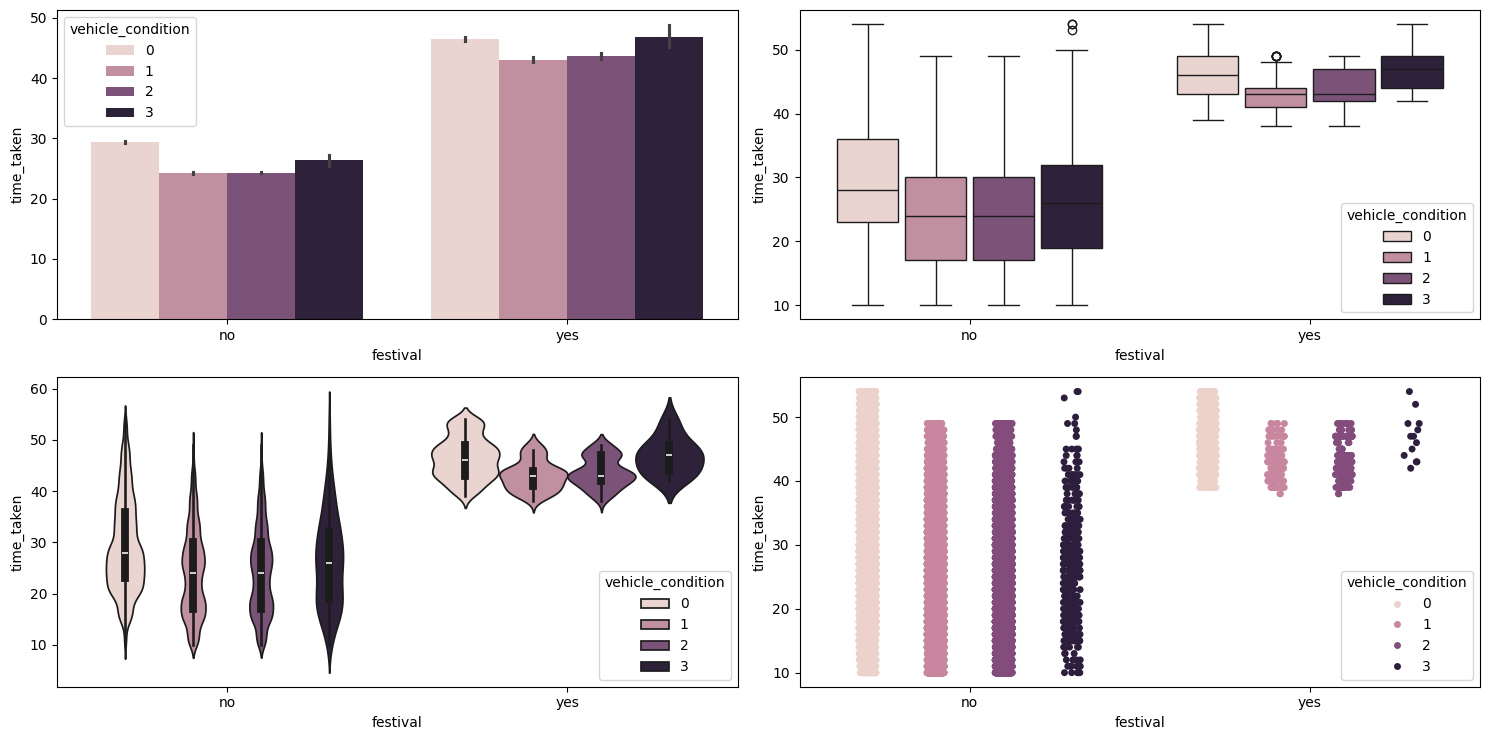

In [57]:
## delivery time on festival and vechile condition
multivariate_analysis(df,'time_taken','festival','vehicle_condition')

multiple delivery

In [58]:
df.shape

(45502, 26)

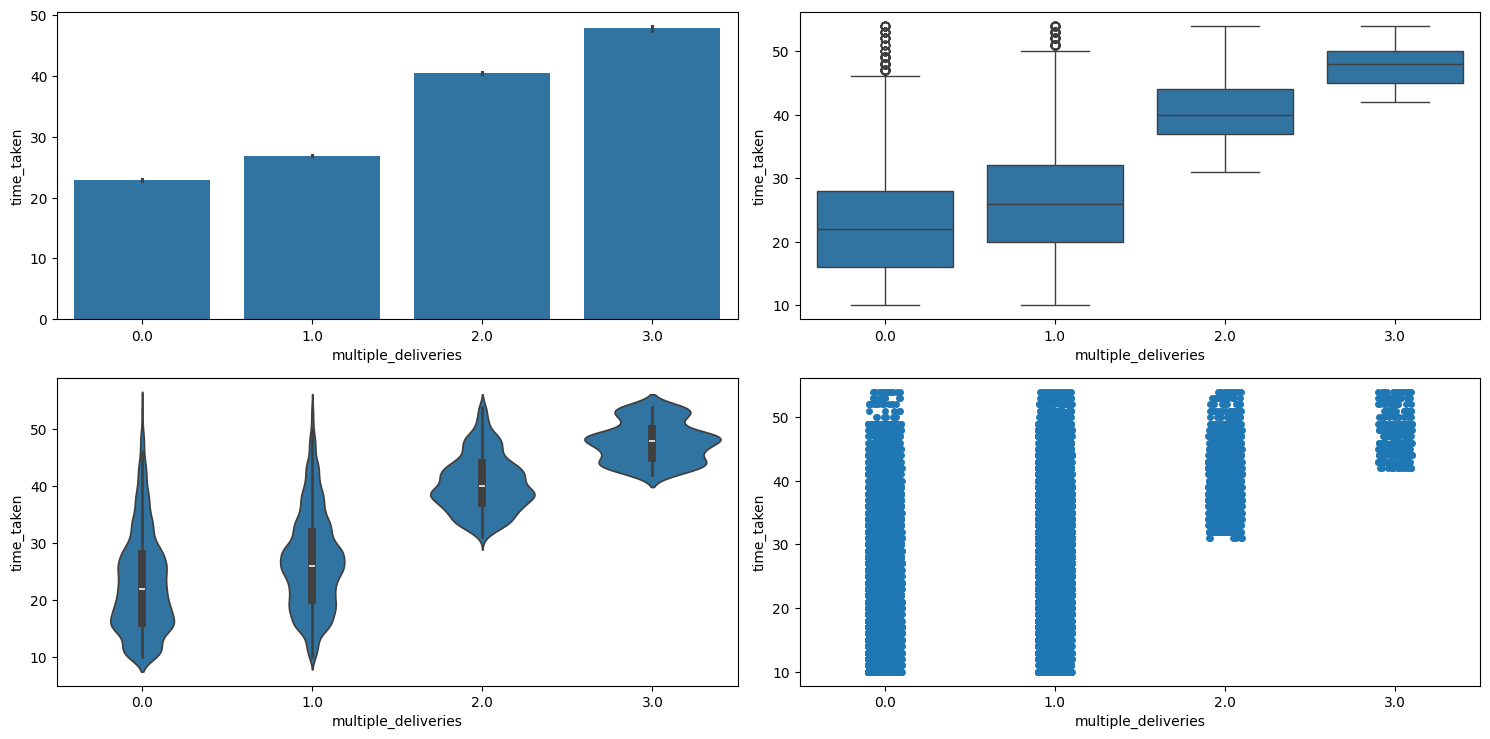

In [59]:
# does multiple delivery affect delivery time
numerical_categorical_analysis(df,'multiple_deliveries','time_taken')

In [60]:
# anova test
anova_test(df,'time_taken','multiple_deliveries')

0.0
reject null hypothesis there is a significant association between time_taken and multiple_deliveries. 


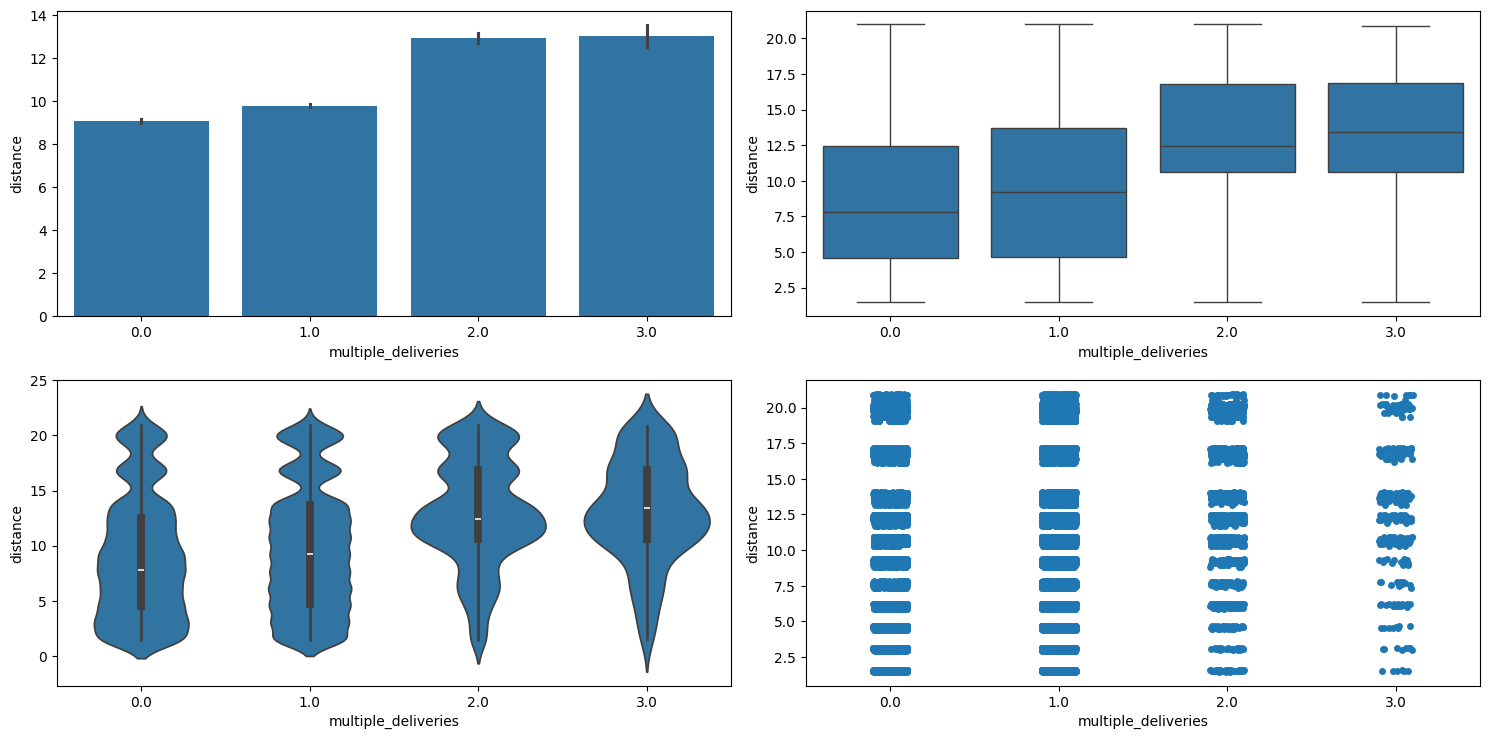

In [61]:
# does multiple delivery for large distance
numerical_categorical_analysis(df,'multiple_deliveries','distance')

wheather

In [62]:
# whearther
df['weather'].dtypes

dtype('O')

,Count,Percentage
weather,,
fog,7654,17.02%
stormy,7586,16.87%
cloudy,7536,16.76%
sandstorms,7495,16.66%
windy,7422,16.5%
sunny,7284,16.19%


number of unique categories 7
**************************************************
number of catgories in weather columns are 7


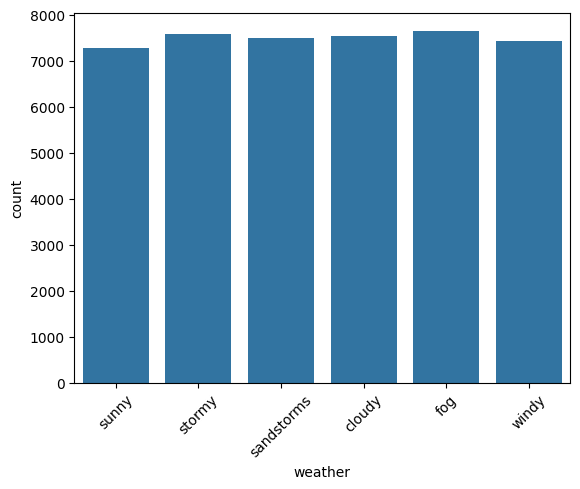

In [63]:
# categorical analysis of weather
categorical_analysis(df,'weather')

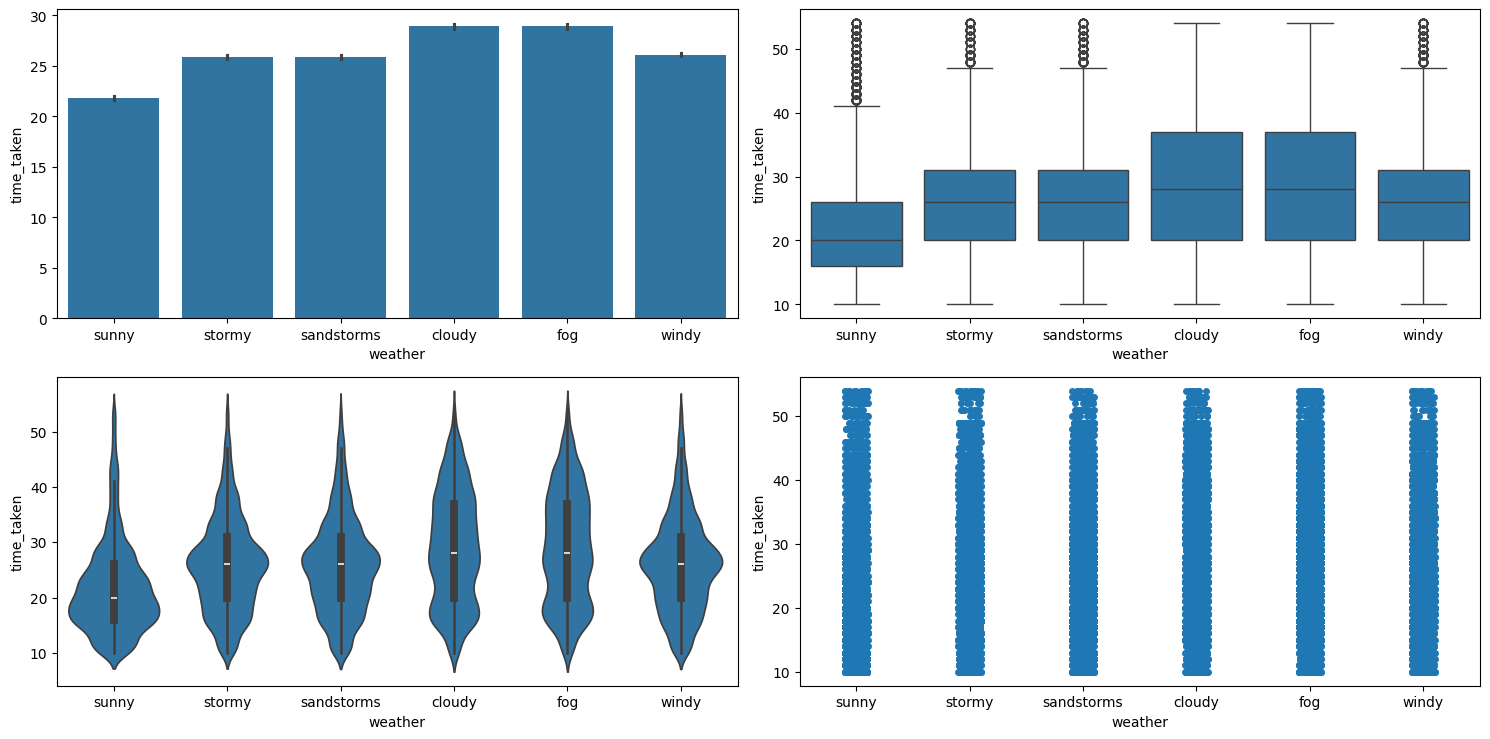

In [64]:
numerical_categorical_analysis(df,'weather','time_taken')

In [65]:
anova_test(df,'time_taken','weather')

0.0
reject null hypothesis there is a significant association between time_taken and weather. 


In [66]:
#does weather affect the traffic
chi_2_test(df,'weather','traffic')

0.4796388074753828
fail to reject null hypothesis there is no significant association between weather and traffic. 


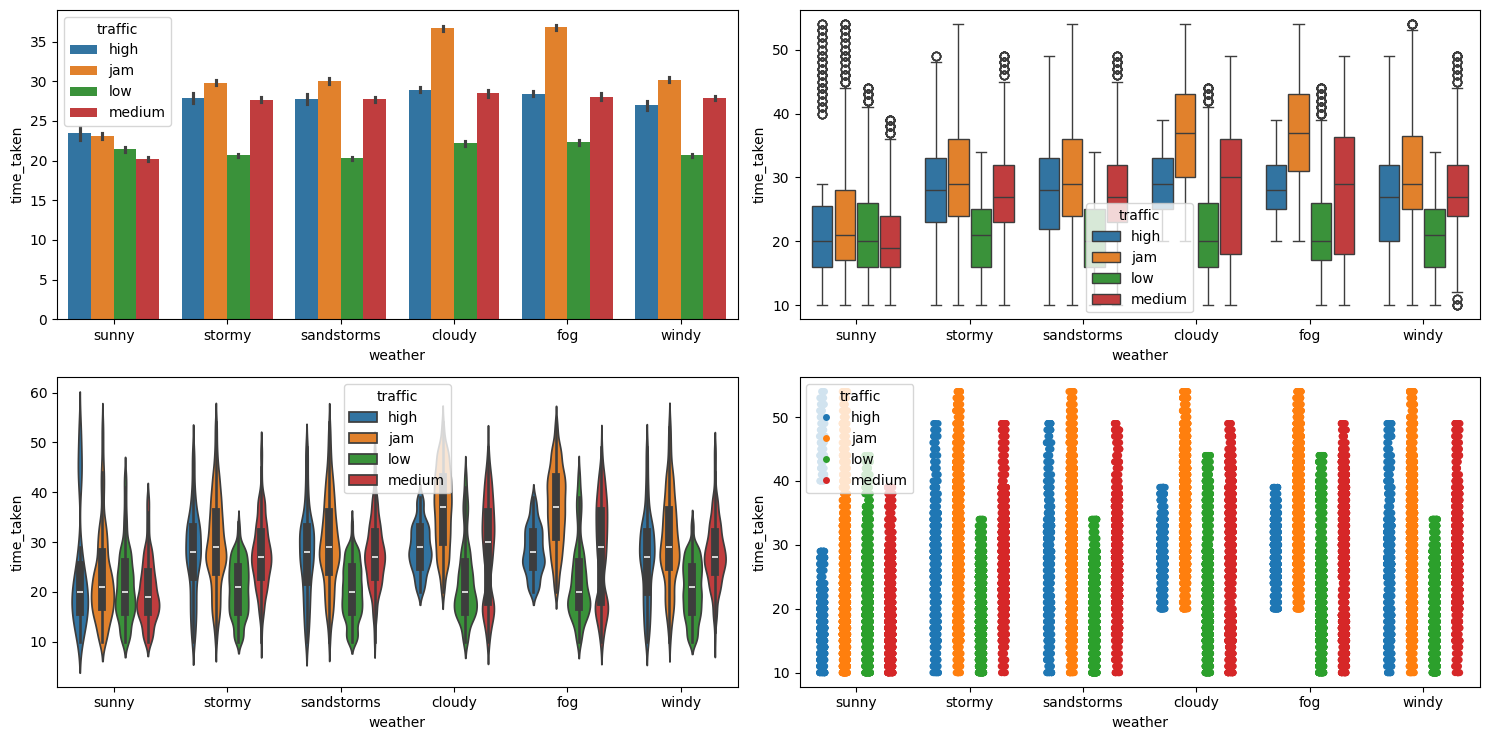

In [67]:
# delivery time affect by weather and traffic
multivariate_analysis(df,'time_taken','weather','traffic')

vechicle-condition and type

,Count,Percentage
vehicle_condition,,
2,15034,33.04%
1,15030,33.03%
0,15009,32.99%
3,429,0.94%


number of unique categories 4
**************************************************
number of catgories in vehicle_condition columns are 4


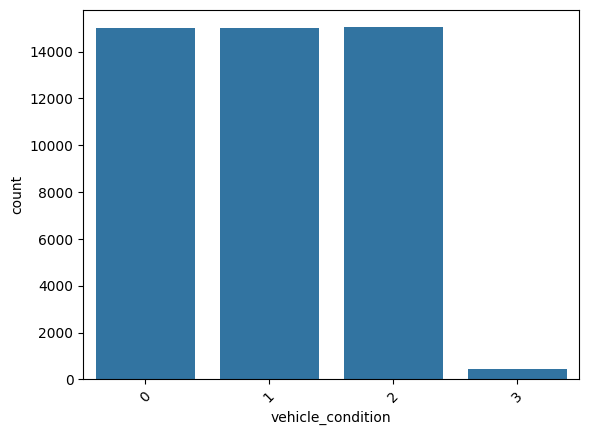

In [68]:
# vechicle-condition and type
categorical_analysis(df,'vehicle_condition')

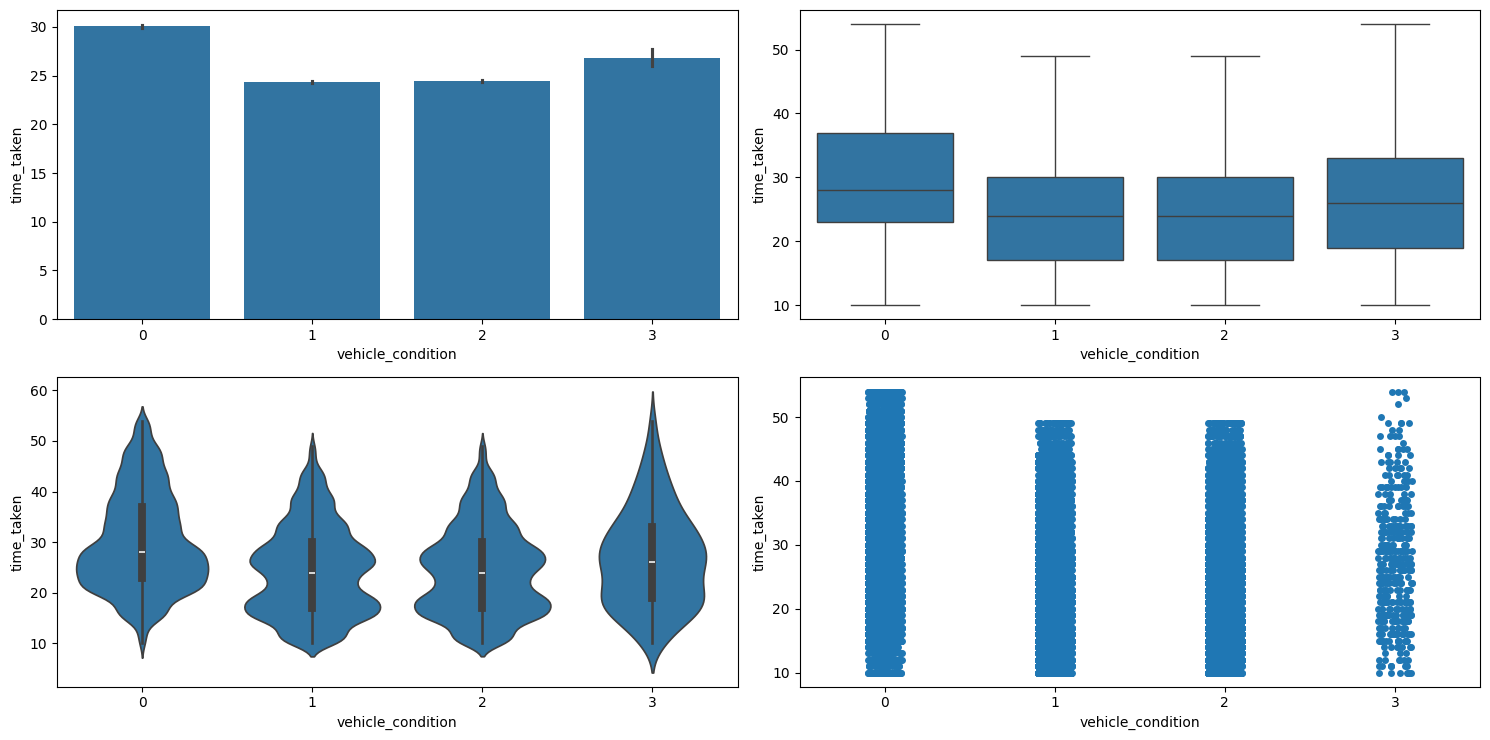

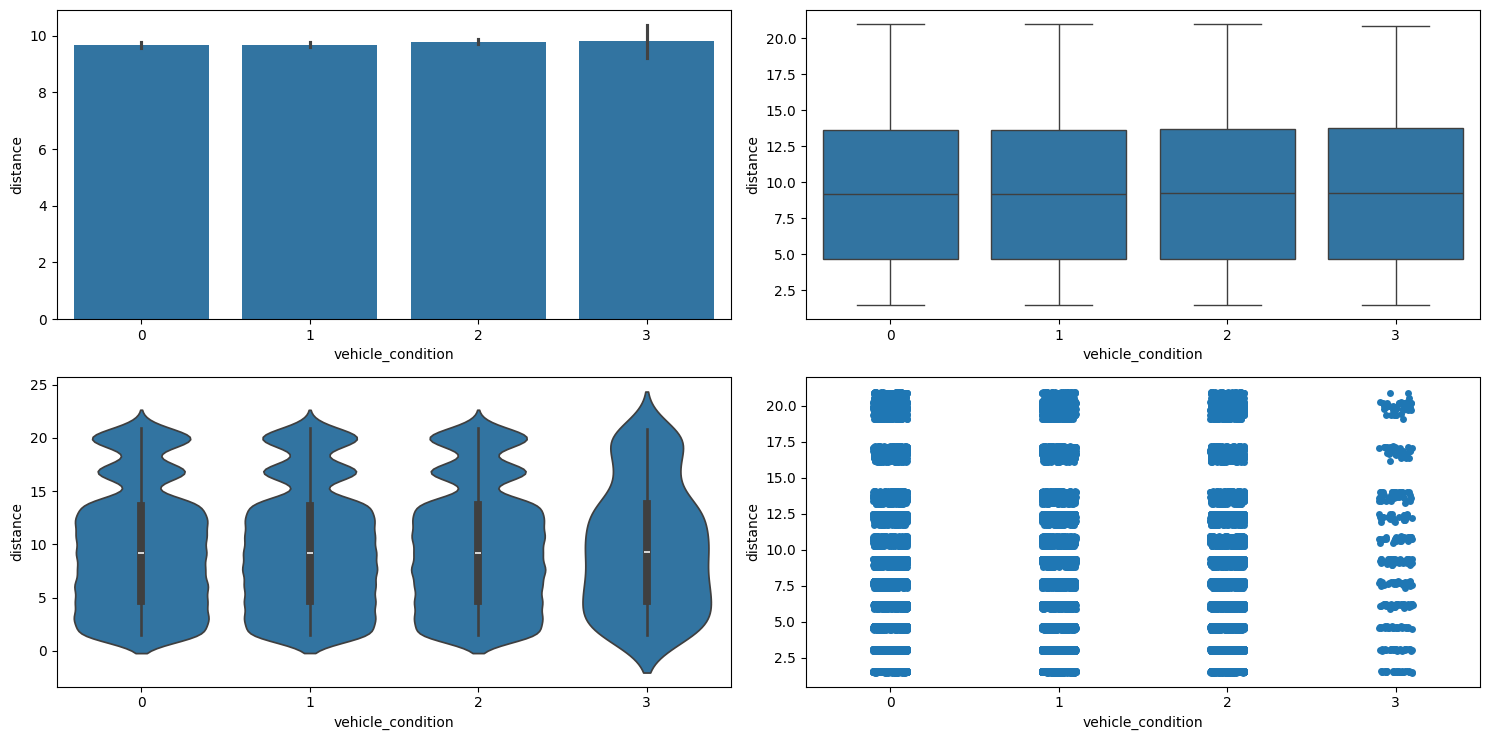

In [70]:
#vechicle condition affect the delivery time
numerical_categorical_analysis(df,'vehicle_condition','time_taken')
numerical_categorical_analysis(df,'vehicle_condition','distance')
# good vechile then assign the longer delivery that'why the time taken by good vechile is more

good vechile then assign the longer delivery that'why the time taken by good vechile is more

In [72]:
# time taken affect by the vehicle condition
anova_test(df,'time_taken','vehicle_condition')

0.0
reject null hypothesis there is a significant association between time_taken and vehicle_condition. 


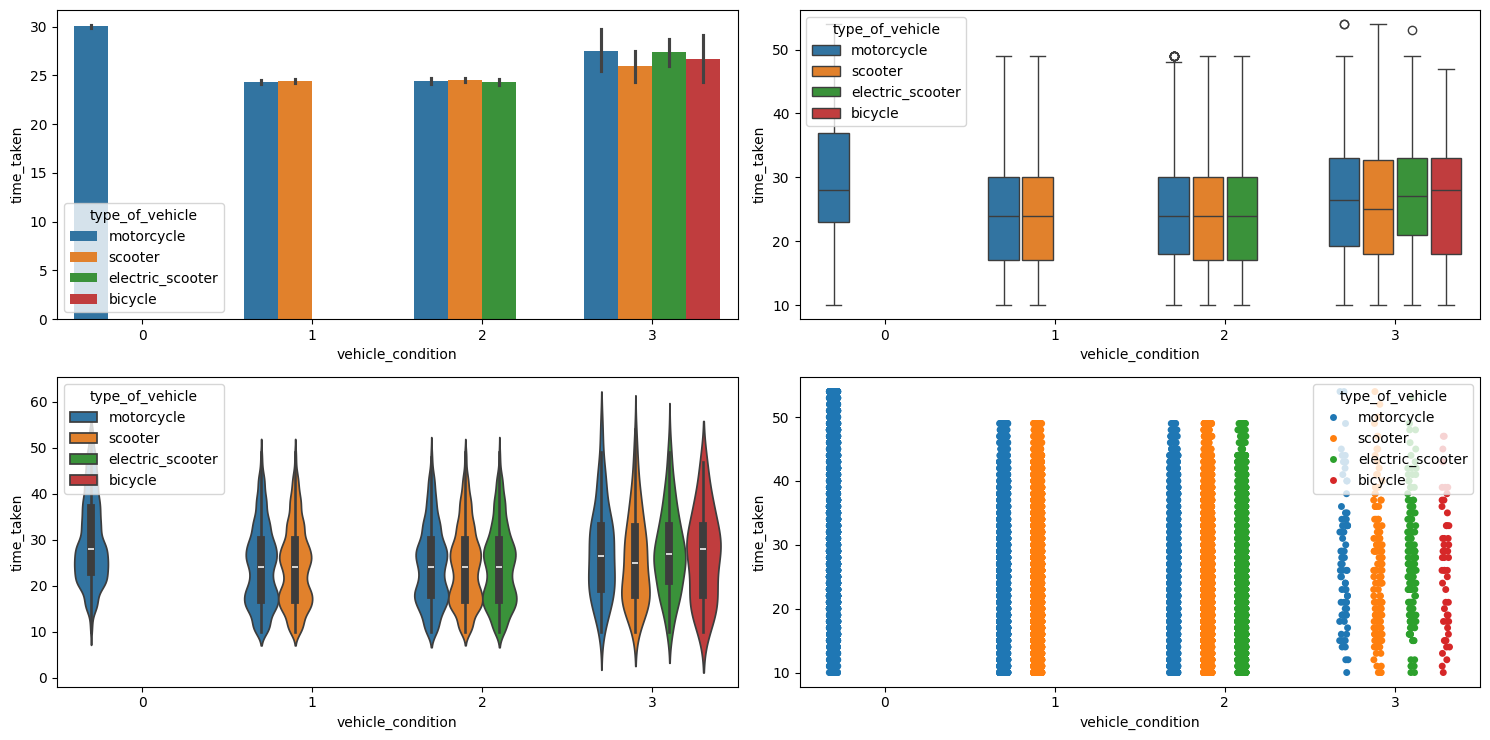

In [74]:
# vehicle condition and type of vehicle
multivariate_analysis(df,'time_taken','vehicle_condition','type_of_vehicle')


In [75]:
# is there is relationship between vechicle condition and vechicle type
chi_2_test(df,'vehicle_condition','type_of_vehicle')


0.0
reject null hypothesis there is a significant association between vehicle_condition and type_of_vehicle. 


in good quality vehicle motercycle is comes

type of order

,Count,Percentage
type_of_order,,
snack,11512,25.3%
meal,11435,25.13%
drinks,11294,24.82%
buffet,11261,24.75%


number of unique categories 4
**************************************************
number of catgories in type_of_order columns are 4


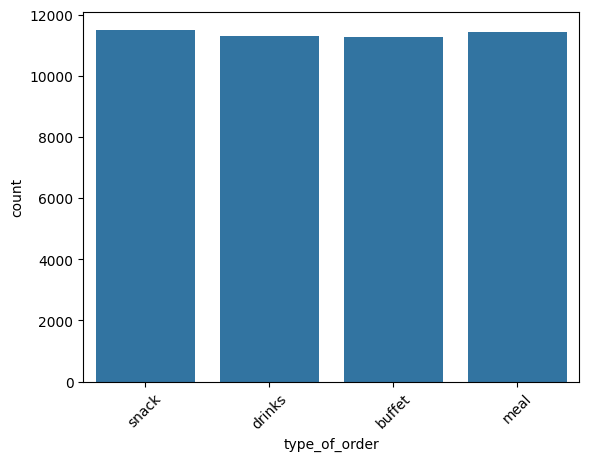

In [76]:
categorical_analysis(df,'type_of_order')

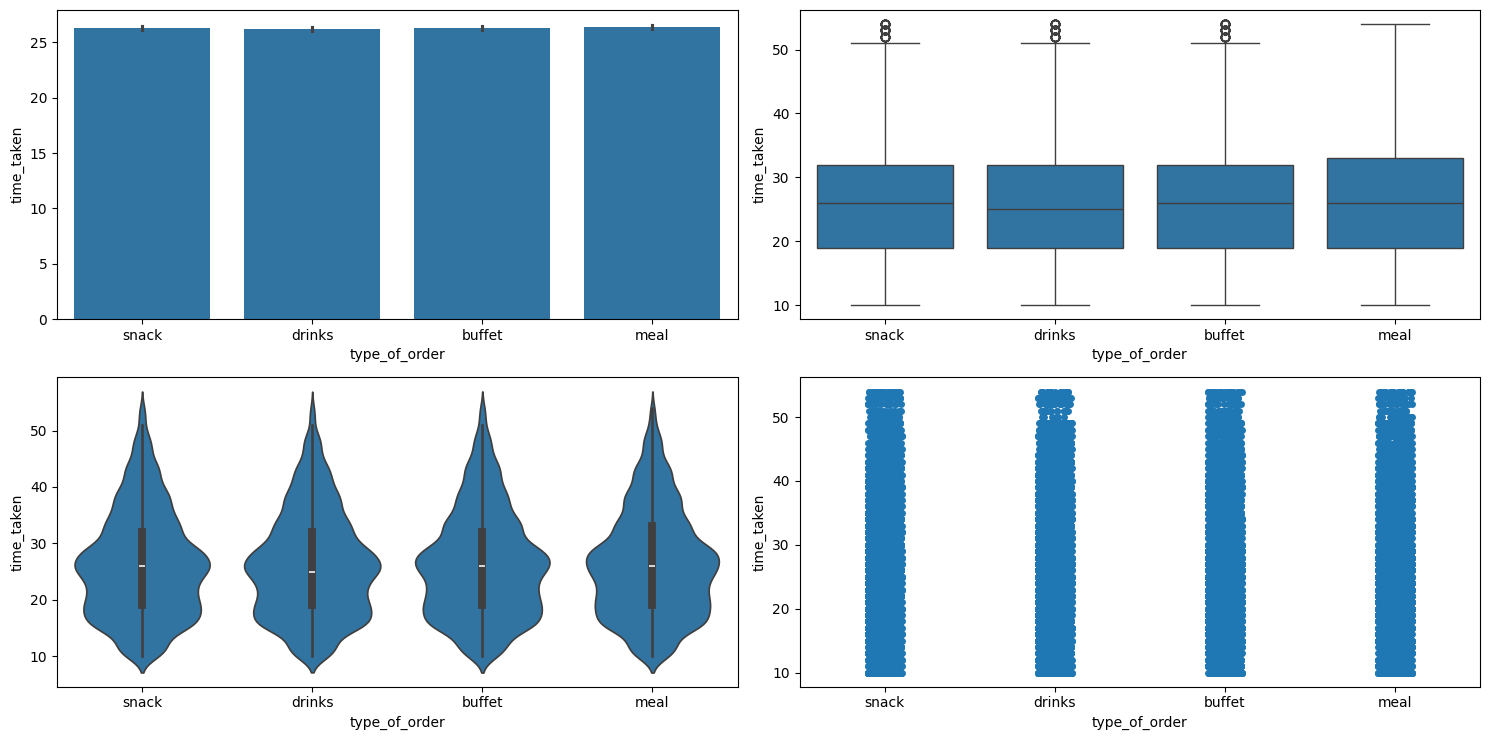

In [77]:
# does type of order affect the delivery time
numerical_categorical_analysis(df,'type_of_order','time_taken')

In [78]:
# test for delivery type
anova_test(df,'time_taken','type_of_order')
# this feature is not affect the delivery time so we can drop this in feature selection

0.3043309877239704
fail to reject null hypothesis there is no significant association between time_taken and type_of_order. 


city name

,Count,Percentage
city_name,,
JAP,3439,7.56%
RANCHI,3222,7.08%
BANG,3184,7.0%
SUR,3182,6.99%
HYD,3177,6.98%
MUM,3168,6.96%
MYS,3164,6.95%
COIMB,3162,6.95%
VAD,3159,6.94%


number of unique categories 22
**************************************************
number of catgories in city_name columns are 22


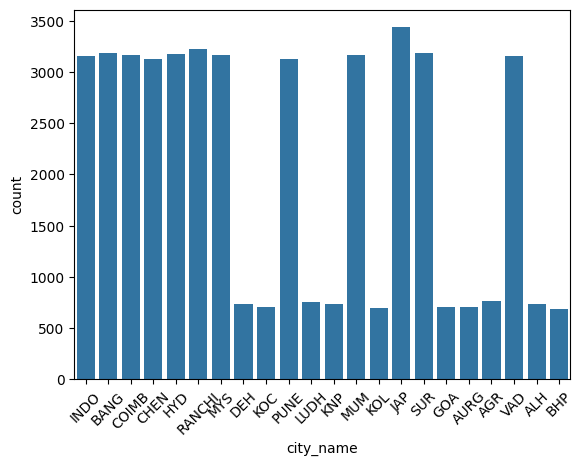

In [80]:
# categorical analysis on city name
categorical_analysis(df,'city_name')

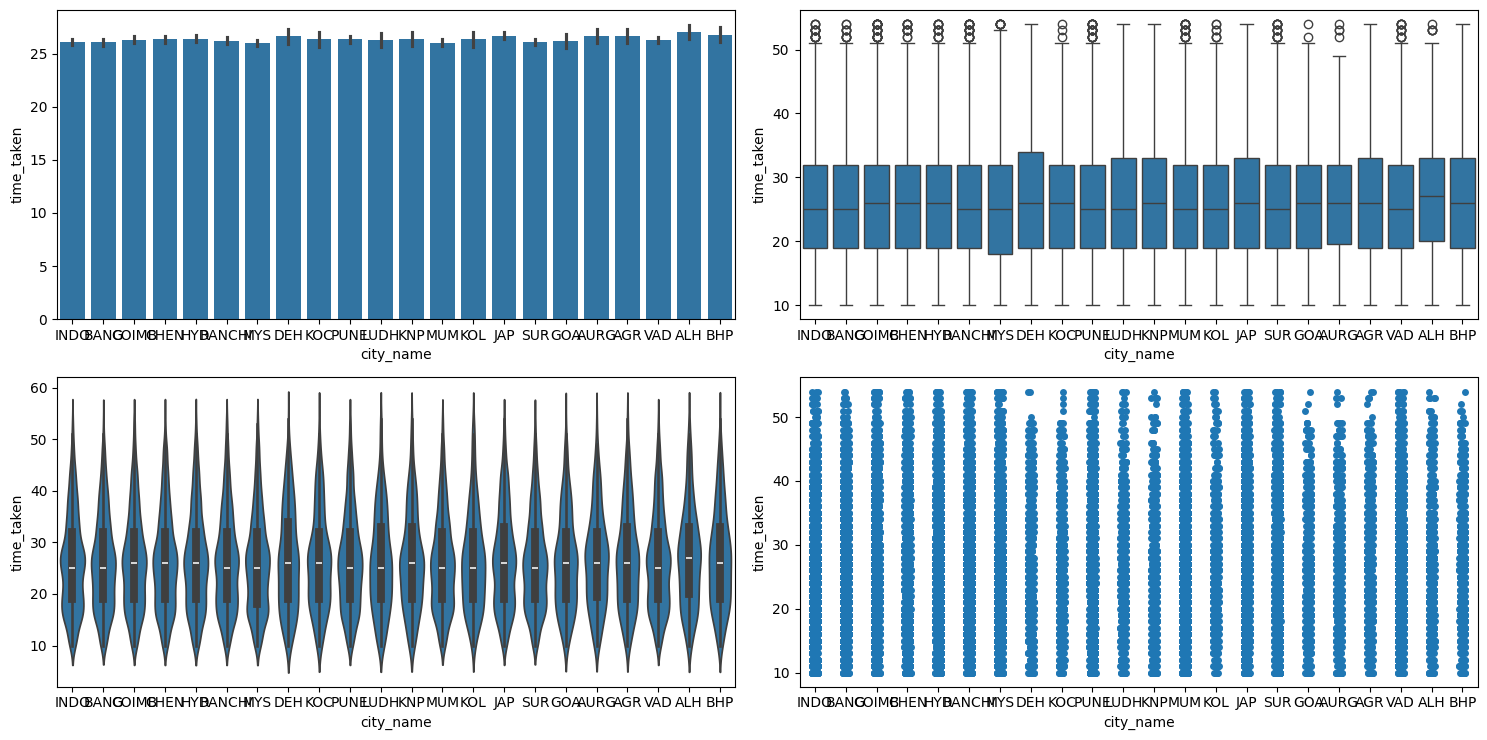

In [81]:
# impact on delivery time of city name
numerical_categorical_analysis(df,'city_name','time_taken')

In [82]:
# test for city impact on delivery time
anova_test(df,'time_taken','city_name')

0.1594719240748443
fail to reject null hypothesis there is no significant association between time_taken and city_name. 


this column also not helpfull for delivery prediction because no impact on delivery time

city type

,Count,Percentage
city_type,,
metropolitian,34029,76.81%
urban,10111,22.82%
semi-urban,164,0.37%


number of unique categories 4
**************************************************
number of catgories in city_type columns are 4


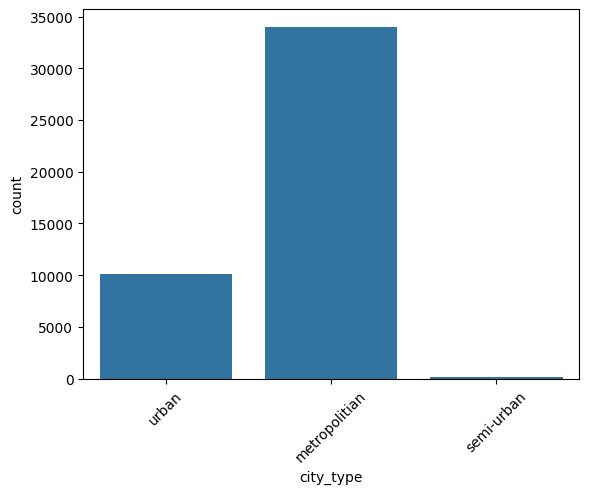

In [83]:
# city type categorical analysis
categorical_analysis(df,'city_type')

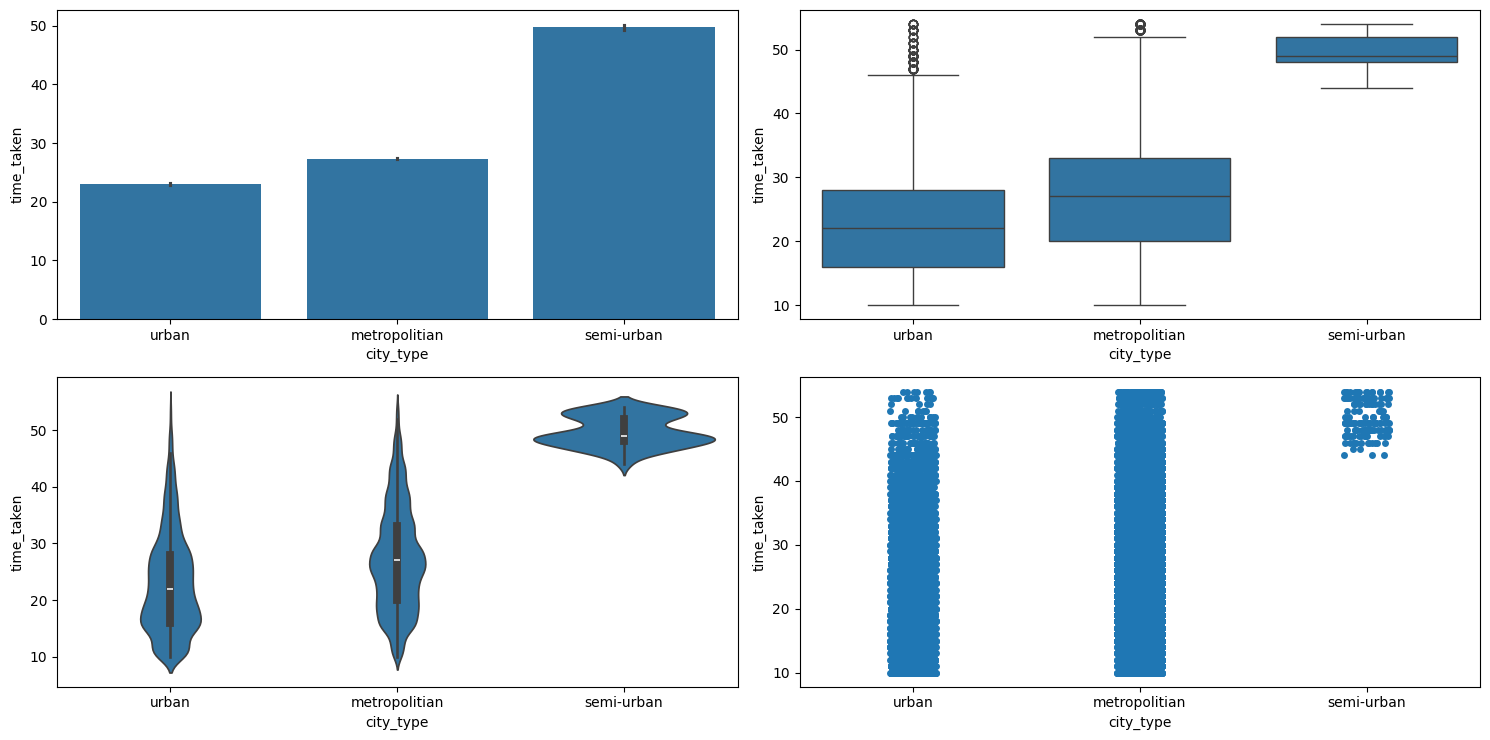

In [84]:
# delivery time affect by the city type
numerical_categorical_analysis(df,'city_type','time_taken')

In [85]:
# test for delivery time affect by city type
anova_test(df,'time_taken','city_type')

##---------- there is significant  association

0.0
reject null hypothesis there is a significant association between time_taken and city_type. 


# distance

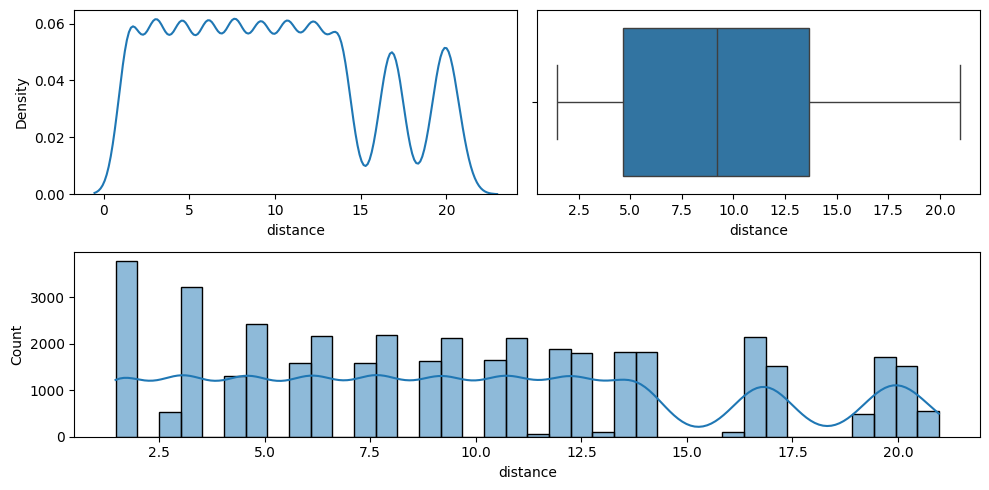

In [86]:
# numerical analysis
numerical_analysis(df,'distance',bins =10)  ## in km


In [89]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'weather', 'traffic', 'vehicle_condition', 'type_of_order',
       'type_of_vehicle', 'multiple_deliveries', 'festival', 'city_type',
       'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutess',
       'order_time_hour', 'order_time_of_day', 'distance',
       'time_taken_transformed'],
      dtype='object')

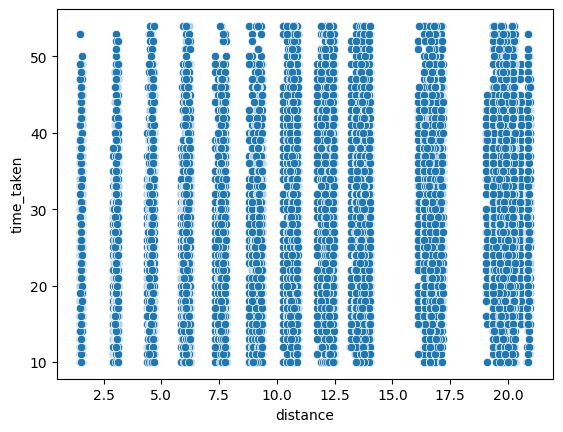

In [88]:
## distance and time-taken
sns.scatterplot(data = df,x ='distance',y='time_taken')
plt.show()

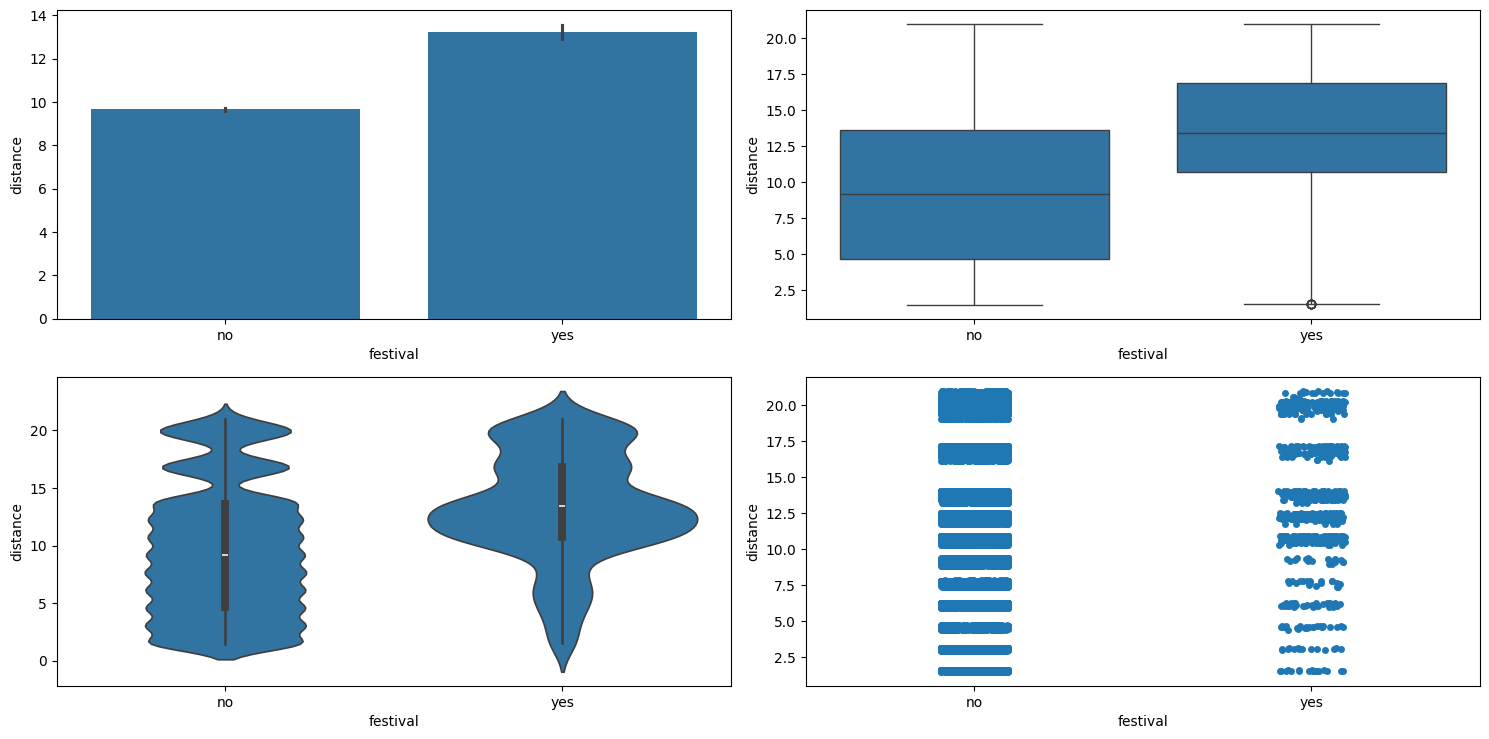

In [90]:
## does festival and distance have realtion
numerical_categorical_analysis(df,'festival','distance')

in festival there is longer delivery

In [91]:
# test for distance and festival
anova_test(df,'distance','festival')

8.002928818857731e-74
reject null hypothesis there is a significant association between distance and festival. 


In [92]:
# type of vechicle and distance test
anova_test(df,'distance','type_of_vehicle')

0.6414275711661958
fail to reject null hypothesis there is no significant association between distance and type_of_vehicle. 
